In [1]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torch import nn
from typing import Any, Dict, Optional, Union
from tqdm import tqdm
import json
import scipy.stats as stats
import numpy as np
from sklearn.preprocessing import StandardScaler


from causalflows.flows import CausalMAF, CausalNSF
from causalflows.scms import SCM, CausalEquations

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## Import our Knowledge graphs

#NOTE we need to put 1 in the diagonal of the adjacency matrix

In [2]:
with open("new_ordered_graphs.json", 'r', encoding='utf-8') as f:
    loaded_graphs = json.load(f)

#loaded_graphs=loaded_graphs[0:2]
selected_graph = loaded_graphs[0]  
variables = selected_graph['variables']
adjacency_matrix = selected_graph['adjacency_matrix']

adj_array = np.array(adjacency_matrix)
# Add ones to the diagonal
np.fill_diagonal(adj_array, 1)

# Convert to torch tensor (boolean)
adjacency = torch.tensor(adj_array, dtype=torch.bool)
adjacency

tensor([[ True, False, False, False, False, False, False],
        [ True,  True, False, False, False, False, False],
        [False, False,  True, False, False, False, False],
        [False,  True, False,  True, False, False, False],
        [ True,  True, False,  True,  True, False, False],
        [ True,  True, False,  True, False,  True, False],
        [ True,  True,  True,  True,  True,  True,  True]])

In [3]:
# Load ground truth model FIRST
checkpoint_gt = torch.load('saved_models_validation/flow_ground_truth.pt',  map_location=torch.device('cpu'),weights_only=False)
scaler_gt = checkpoint_gt['scaler']  # Usar el scaler guardado
gt_variables = checkpoint_gt['variables']

## Import our diabetes dataset

In [4]:
data_df = pd.read_csv("TFM_dataset.csv")

# Drop patient ID column 
data_df = data_df.drop(columns=['randid'])

data_df = data_df[gt_variables]

# Fill missing BMI values with mode
bmi_mode = data_df['bmi'].mode()[0]
data_df['bmi'] = data_df['bmi'].fillna(bmi_mode)


Check if NaNs in the data and handle them accordingly

In [5]:
diabetes_idx = variables.index('diabetes mellitus')

total_diabetes = (data_df['diabetes mellitus'] == 1).sum()
total_no_diabetes = (data_df['diabetes mellitus'] == 0).sum()
print(f" Total dataset:")
print(f"   Diabetes = 1: {total_diabetes} ({total_diabetes/len(data_df)*100:.1f}%)")
print(f"   Diabetes = 0: {total_no_diabetes} ({total_no_diabetes/len(data_df)*100:.1f}%)")

 Total dataset:
   Diabetes = 1: 121 (2.7%)
   Diabetes = 0: 4313 (97.3%)


In [6]:
# Identify binary variables
binary_vars = []
for col in data_df.columns:
    unique_vals = sorted(data_df[col].unique())
    if len(unique_vals) == 2 and set(unique_vals).issubset({0.0, 1.0}):
        binary_vars.append(col)
        prop = (data_df[col] == 1).mean()
        print(f"Binary variable: {col:40s}: {prop:.1%}")

continuous_vars = [col for col in data_df.columns if col not in binary_vars]

# Usar el scaler del modelo cargado (después de cargar el modelo)

# Prepare data with LOADED scaler
data_normalized = data_df.copy()
np.random.seed(42)

# Normalize only continuous variables using LOADED scaler
if len(continuous_vars) > 0:
    continuous_indices = [data_df.columns.get_loc(c) for c in continuous_vars]
    # TRANSFORM (no fit_transform) con el scaler cargado
    data_normalized.iloc[:, continuous_indices] = scaler_gt.transform(
        data_df.iloc[:, continuous_indices]
    )

# Add noise to binary variables AFTER normalization
for col in binary_vars:
    noise_std = 0.03 if (data_df[col] == 1).mean() < 0.05 else 0.05
    noise = np.random.normal(0, noise_std, size=len(data_df))
    data_normalized[col] = data_df[col].astype(float) + noise

# STRATIFIED SPLIT
diabetes_labels = data_df['diabetes mellitus'].values

train_idx, test_idx = train_test_split(
    np.arange(len(data_normalized)),
    test_size=0.1,
    stratify=diabetes_labels,
    random_state=42
)

# Tensors
data_tensor = torch.tensor(data_normalized.values, dtype=torch.float32)

Binary variable: diabetes mellitus                       : 2.7%
Binary variable: cardiac ischemia                        : 16.5%
Binary variable: major acute cardiovascular event        : 26.1%


/tmp/ipykernel_24012/505219346.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.25932027 -0.45249227 -0.22196998 ...  0.23907459 -1.14405912
 -1.25932027]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_normalized.iloc[:, continuous_indices] = scaler_gt.transform(
/tmp/ipykernel_24012/505219346.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.09245627 -0.17959929 -0.26258628 ... -0.01362529  1.23117969
  0.23533571]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_normalized.iloc[:, continuous_indices] = scaler_gt.transform(
/tmp/ipykernel_24012/505219346.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.20464005e+00 -5.35512949e-01 -2.23253637e-01 ...  4.4397

In [7]:
train_data = data_tensor[train_idx]
test_data = data_tensor[test_idx]

features = len(variables)

#context number of additional variables
context = 0


In [8]:
# Load ground truth model
flow_gt = CausalNSF(
    checkpoint_gt['features'],
    0,
    adjacency=checkpoint_gt['adjacency'],
    hidden_features=checkpoint_gt['config']['hidden_dims']
)
flow_gt.load_state_dict(checkpoint_gt['model_state_dict'])
flow_gt.eval()

CausalNSF(
  (transform): MaskedAutoregressiveTransform(
    (base): MonotonicRQSTransform(bins=8)
    (passes): 5
    (hyper): MaskedMLP(
      (0): MaskedLinear(in_features=7, out_features=32, bias=True)
      (1): ReLU()
      (2): MaskedLinear(in_features=32, out_features=32, bias=True)
      (3): ReLU()
      (4): MaskedLinear(in_features=32, out_features=161, bias=True)
    )
  )
  (base): UnconditionalDistribution(DiagNormal(loc: torch.Size([7]), scale: torch.Size([7])))
)

In [9]:
# # len(loaded_graphs)
# loaded_graphs=loaded_graphs[0:2]
loaded_graphs=loaded_graphs[0:100]

### Load Models

In [10]:
# Load all models
loaded_models = []

for graph_idx in range(len(loaded_graphs)):
    # Load selected graph model
    checkpoint_selected = torch.load(
        f'saved_models_validation/flow_selected_graph_{graph_idx}.pt',
        map_location=torch.device('cpu'),
        weights_only=False  
    )
    flow_selected = CausalNSF(
        checkpoint_selected['features'],
        0,
        adjacency=checkpoint_selected['adjacency'],
        hidden_features=checkpoint_selected['config']['hidden_dims']
    )
    flow_selected.load_state_dict(checkpoint_selected['model_state_dict'])
    flow_selected.eval()
    
    loaded_models.append({
        'flow_selected': flow_selected,
        'variables': checkpoint_selected['variables'],
        'scaler': checkpoint_selected['scaler'], 
    })

print(f"Loaded {len(loaded_models)} model pairs")

Loaded 100 model pairs


In [11]:
def create_df(tensors_dict, var_order=None):
    """
    Create DataFrame from tensors or numpy arrays.
    
    Args:
        tensors_dict: dict of {name: tensor or numpy array}
        var_order: list of variable names (if None, uses global variables)
    """
    if var_order is None:
        var_order = variables
        
    df_list = []
    for i, (k, x) in enumerate(tensors_dict.items()):
        # Handle both torch tensors and numpy arrays
        if isinstance(x, torch.Tensor):
            x_np = x.numpy()
        else:
            x_np = x  # Already numpy array
            
        df = pd.DataFrame(x_np, columns=var_order)
        df['name'] = k
        df_list.append(df)

    df = pd.concat(df_list)
    return df

def plot_data(tensors_dict, var_order=None):
    """Plot data with consistent variable ordering."""
    df = create_df(tensors_dict, var_order)
    g = sns.PairGrid(df, diag_sharey=False, hue='name')
    g.map_upper(sns.scatterplot, s=15, alpha=0.5)
    g.map_lower(sns.kdeplot, common_norm=False)
    g.map_diag(sns.kdeplot, lw=2, common_norm=False)
    g.add_legend()
    plt.show()


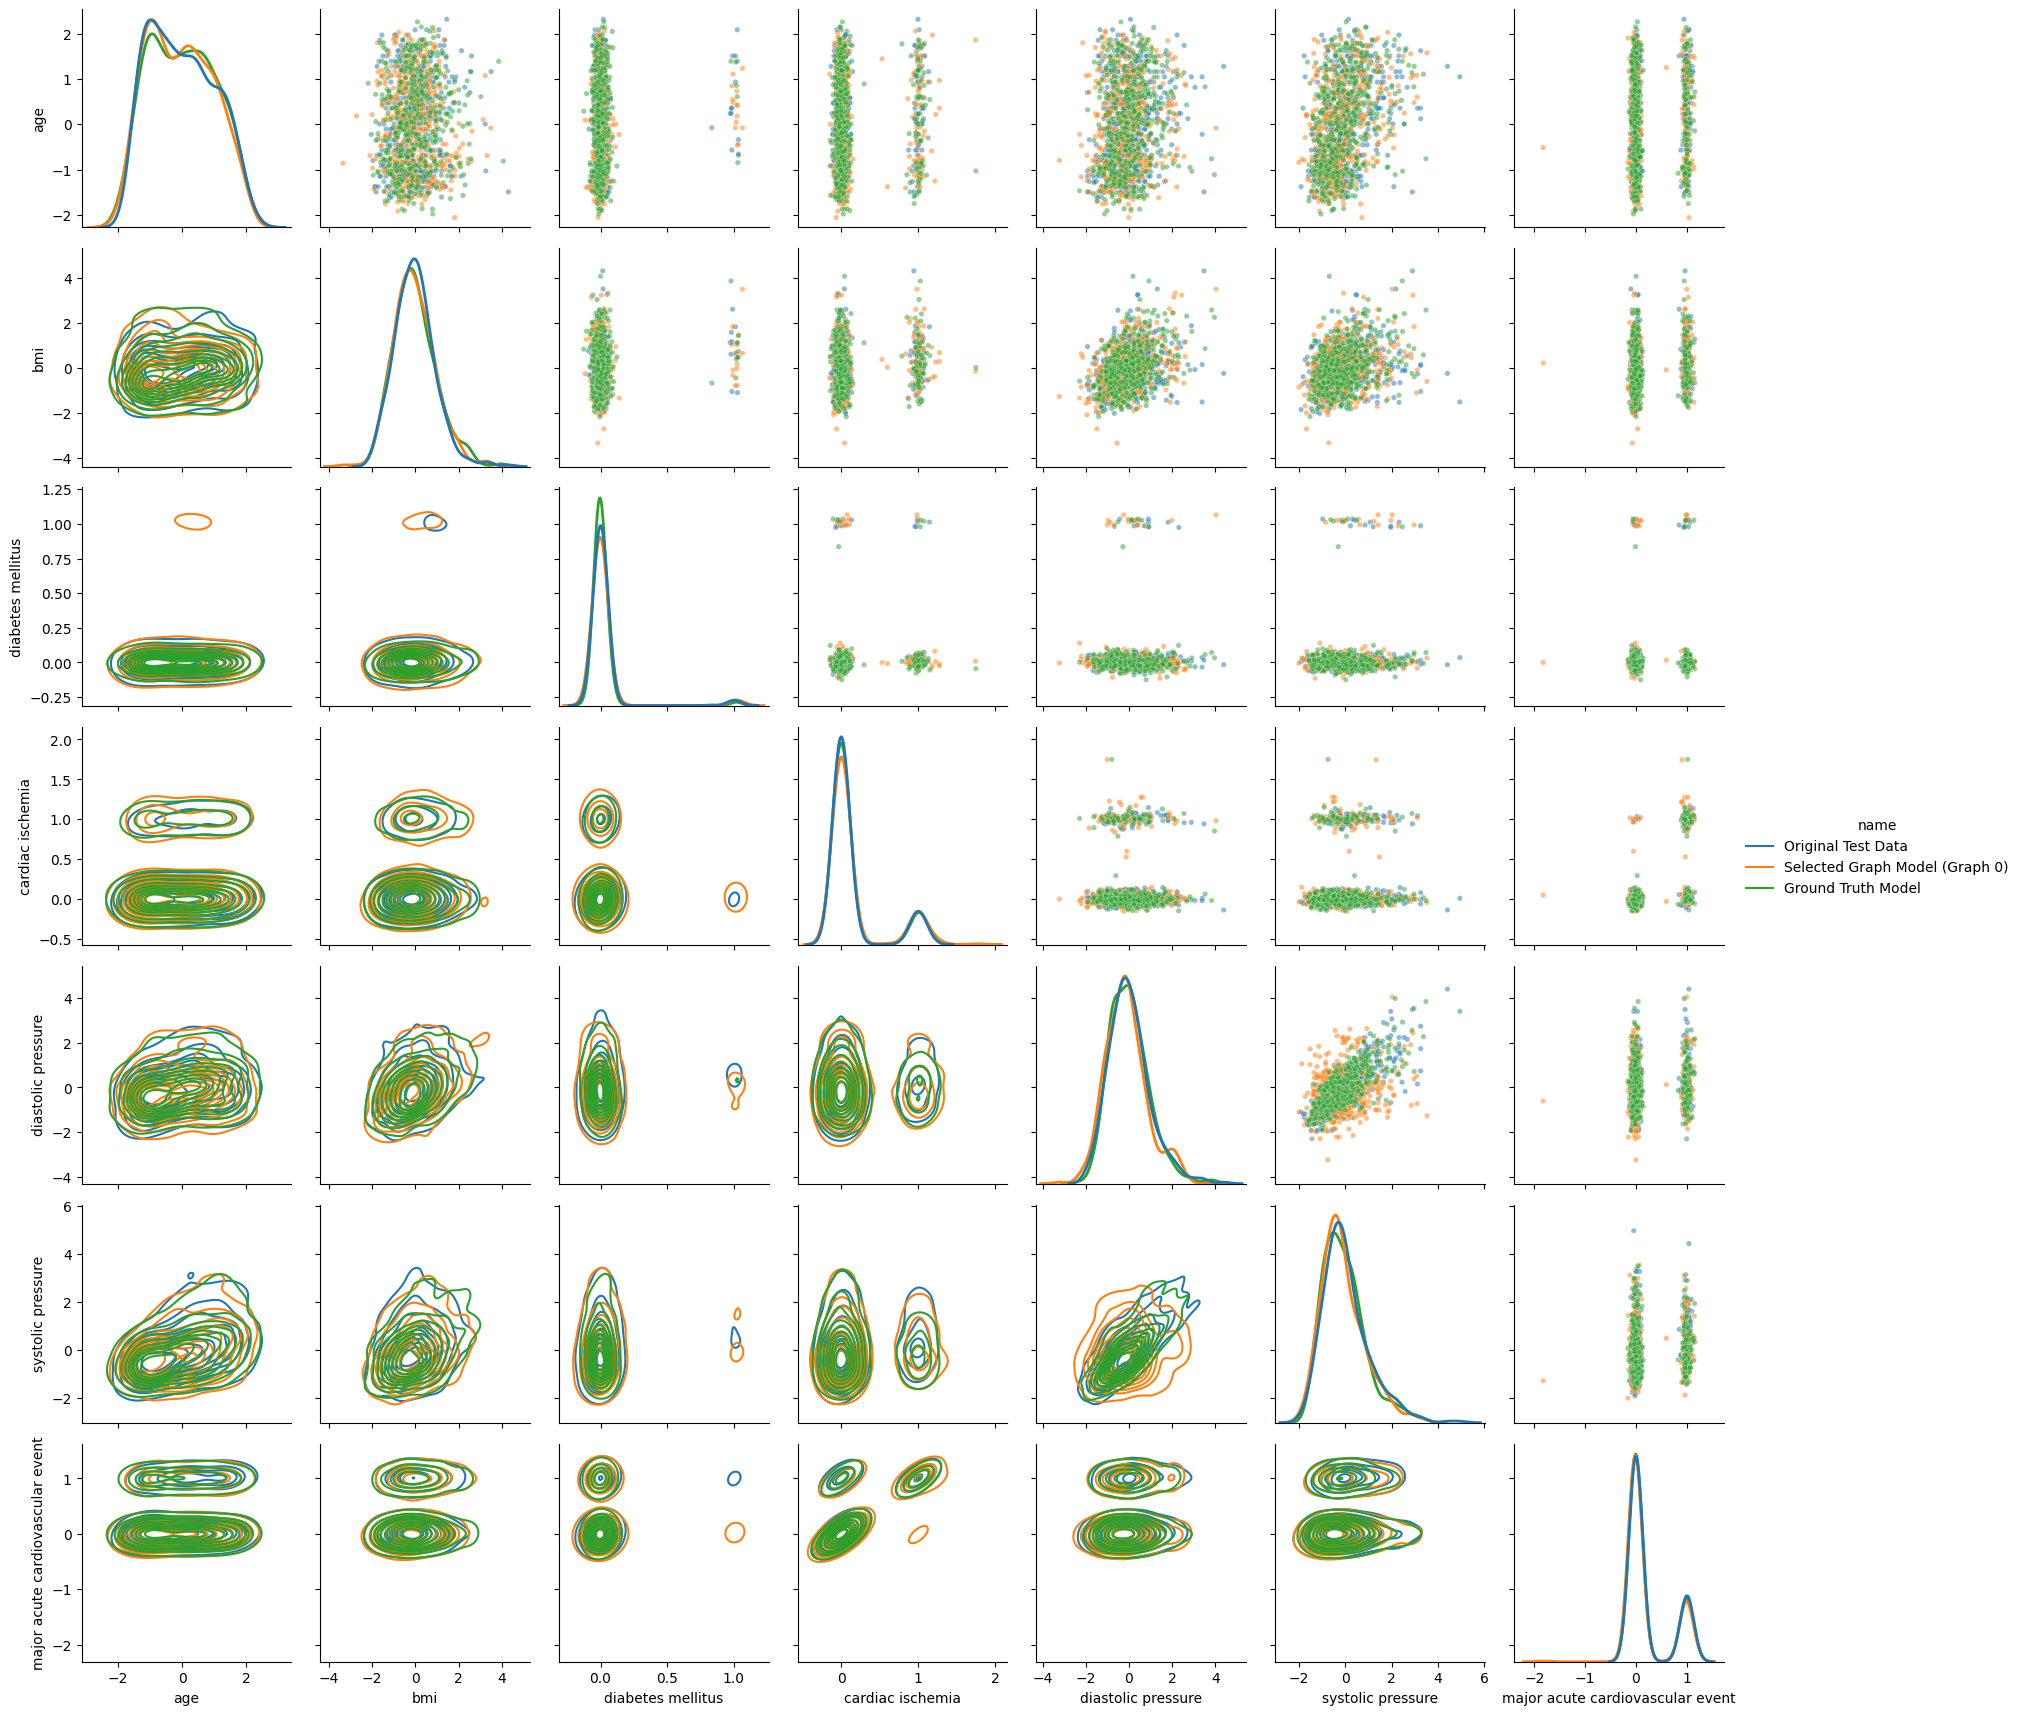

In [ ]:
test_size= len(test_data)
model_idx = 0
flow_prueba = loaded_models[model_idx]
flow_selected = flow_prueba['flow_selected']
variables_selected = flow_prueba['variables']  # Variables del grafo seleccionado
scaler_selected = flow_prueba['scaler']

# Get ground truth variable order
gt_vars = checkpoint_gt['variables']

# Generate samples
gen_data_selected = flow_selected().sample([test_size]).numpy()
gen_data_gt = flow_gt().sample([test_size]).numpy()

# test_data YA está en orden GT (porque data_df = data_df[gt_variables])
# Solo necesitas reordenar gen_data_selected desde Graph 0 order → GT order
reorder_indices = [variables_selected.index(var) for var in gt_vars]
gen_data_selected_reordered = gen_data_selected[:, reorder_indices]

# Convert to tensors
gen_data_selected_reordered = torch.tensor(gen_data_selected_reordered)
gen_data_gt = torch.tensor(gen_data_gt)

# Plot with GT variable order
plot_data({
    'Original Test Data': test_data,  # Ya está en orden GT, no necesita reordenamiento
    'Selected Graph Model (Graph 0)': gen_data_selected_reordered,
    'Ground Truth Model': gen_data_gt
}, var_order=gt_vars)

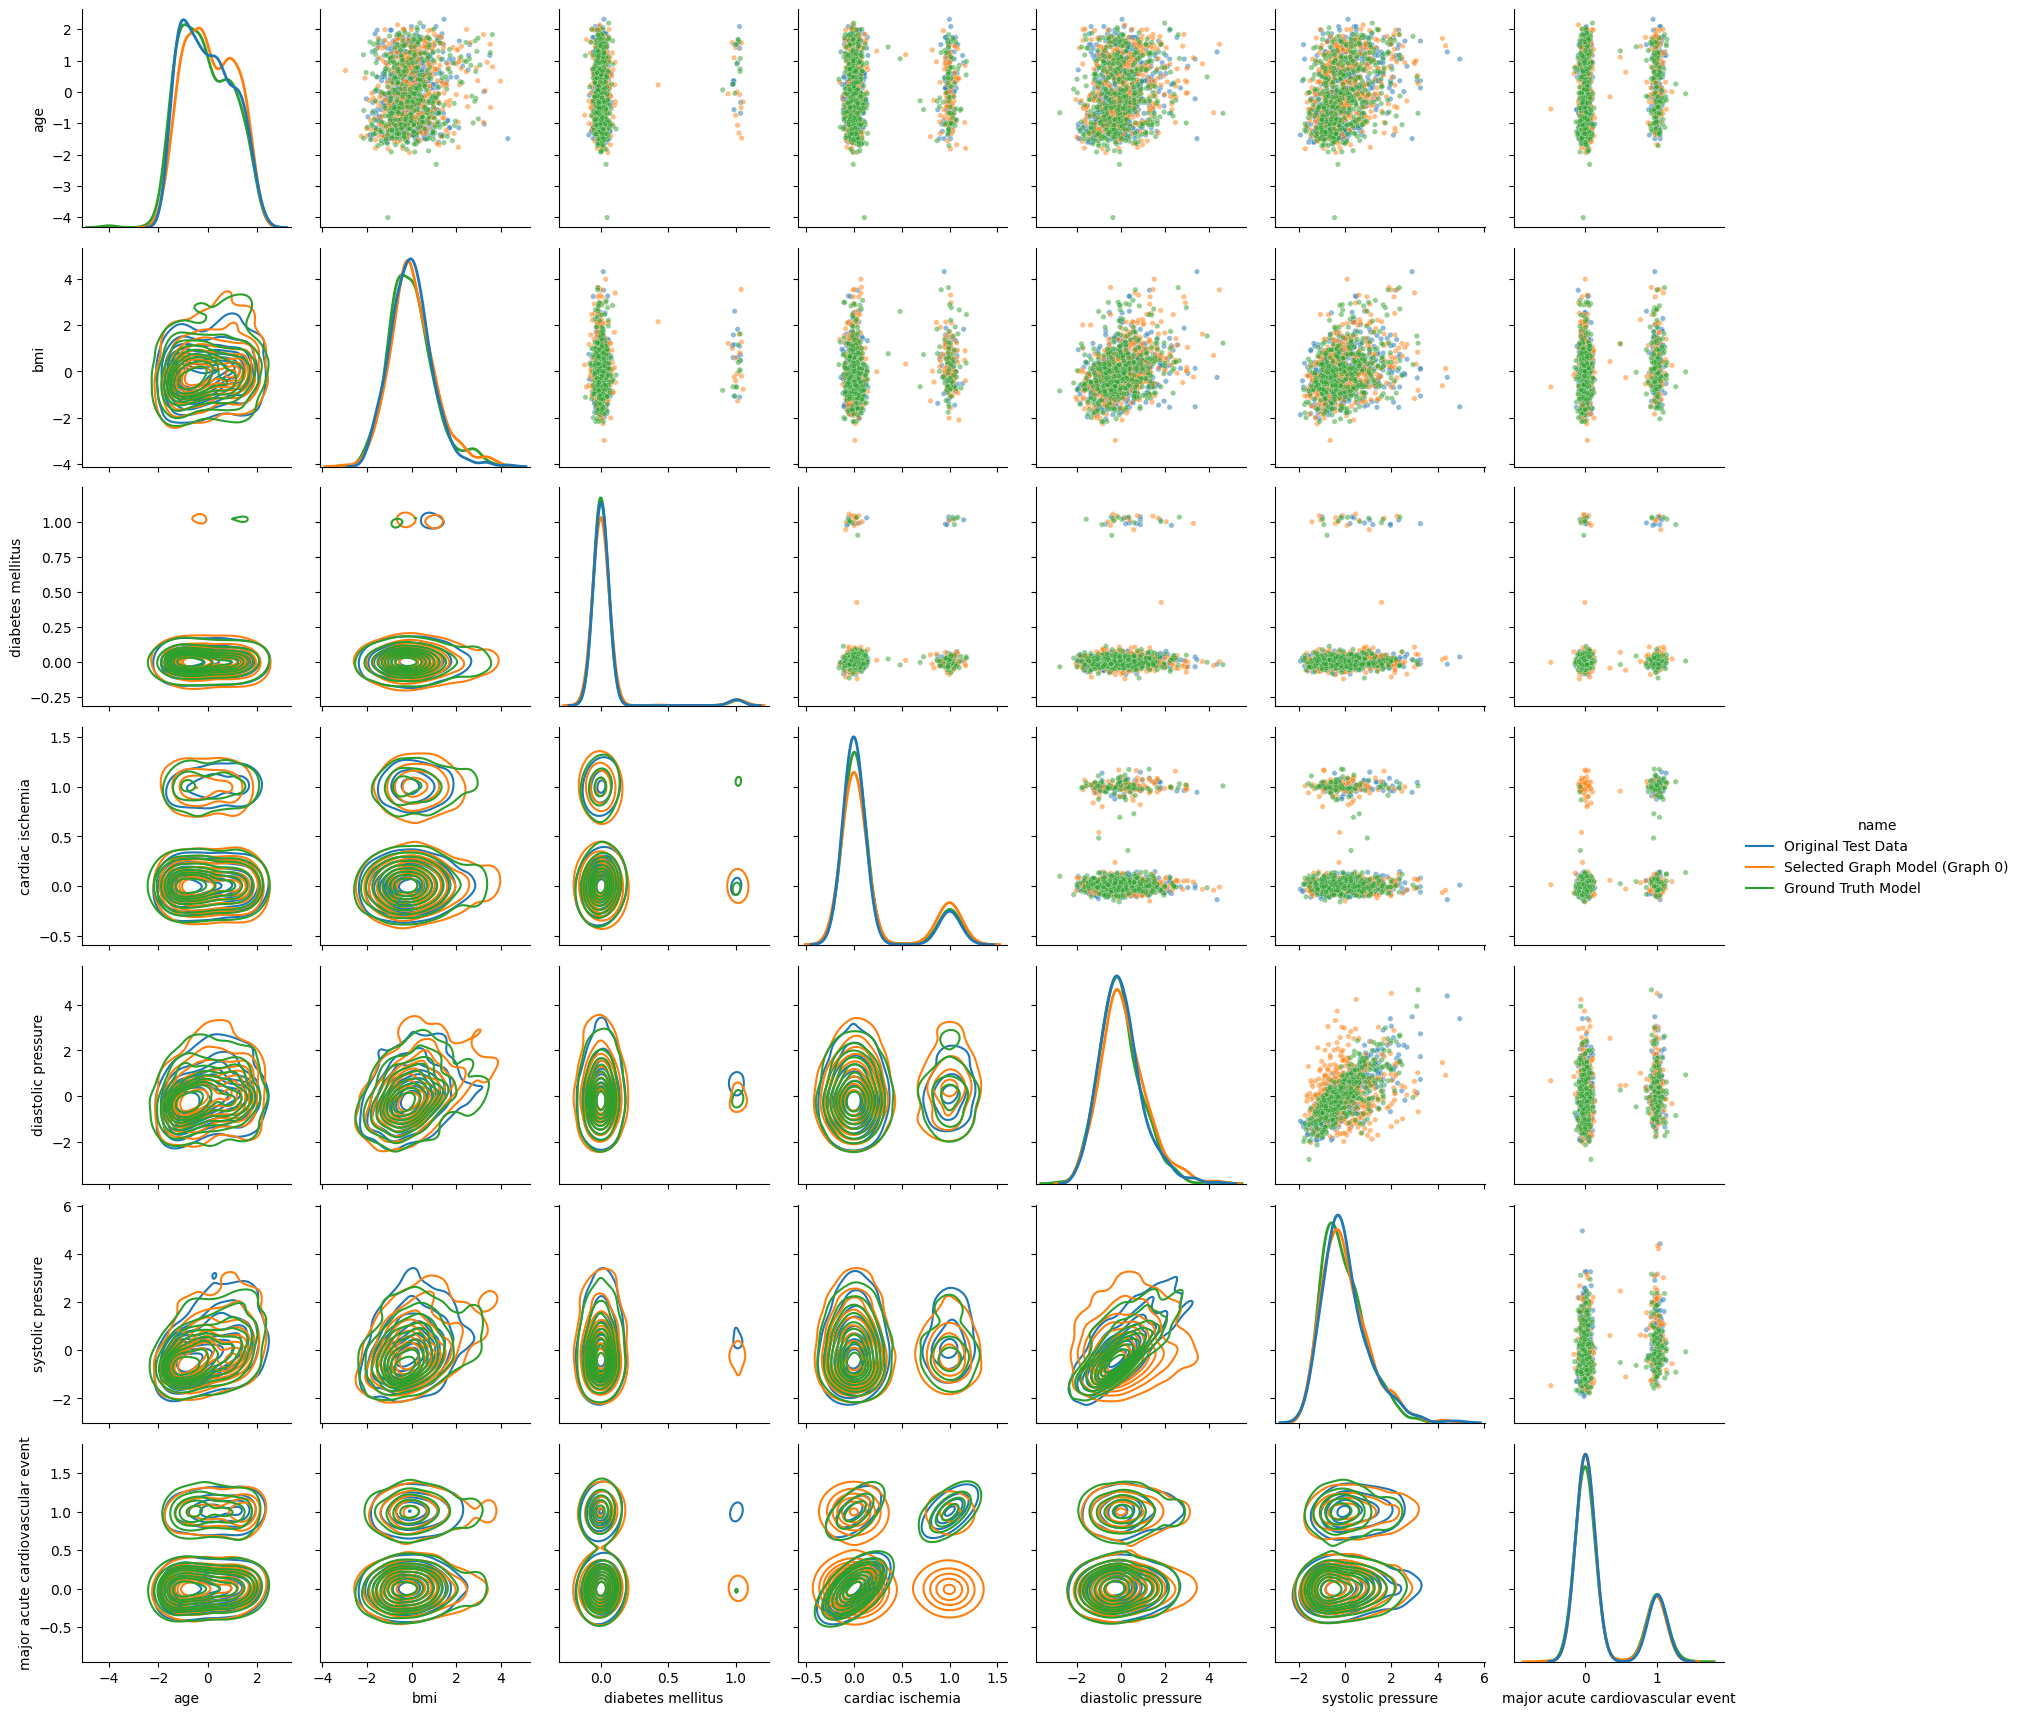

In [ ]:
test_size= len(test_data)
model_idx = 1
flow_prueba = loaded_models[model_idx]
flow_selected = flow_prueba['flow_selected']
variables_selected = flow_prueba['variables']  # Variables del grafo seleccionado
scaler_selected = flow_prueba['scaler']

# Get ground truth variable order
gt_vars = checkpoint_gt['variables']

# Generate samples
gen_data_selected = flow_selected().sample([test_size]).numpy()
gen_data_gt = flow_gt().sample([test_size]).numpy()

reorder_indices = [variables_selected.index(var) for var in gt_vars]
gen_data_selected_reordered = gen_data_selected[:, reorder_indices]

# Convert to tensors
gen_data_selected_reordered = torch.tensor(gen_data_selected_reordered)
gen_data_gt = torch.tensor(gen_data_gt)

# Plot with GT variable order
plot_data({
    'Original Test Data': test_data,  # Ya está en orden GT, no necesita reordenamiento
    'Selected Graph Model (Graph 0)': gen_data_selected_reordered,
    'Ground Truth Model': gen_data_gt
}, var_order=gt_vars)

In [ ]:
flow_prueba['flow_selected']
# plot history
plt.figure(figsize=(8, 5))
plt.plot(history['train_nll'], label='Train NLL')
plt.plot(history['val_nll'], label='Test NLL')
plt.xlabel('Epoch')
plt.ylabel('Negative Log-Likelihood')
plt.title('Training History')
plt.legend()
plt.grid()
plt.show()

CausalNSF(
  (transform): MaskedAutoregressiveTransform(
    (base): MonotonicRQSTransform(bins=8)
    (passes): 4
    (hyper): MaskedMLP(
      (0): MaskedLinear(in_features=7, out_features=64, bias=True)
      (1): ReLU()
      (2): MaskedLinear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
      (4): MaskedLinear(in_features=64, out_features=161, bias=True)
    )
  )
  (base): UnconditionalDistribution(DiagNormal(loc: torch.Size([7]), scale: torch.Size([7])))
)

In [33]:
history= flow_prueba.get('history', None)

plt.figure(figsize=(8, 5))
plt.plot(history['train_nll'], label='Train NLL')
plt.plot(history['val_nll'], label='Validation NLL')
plt.xlabel('Epoch')
plt.ylabel('Negative Log-Likelihood')
plt.title('Training History')
plt.legend()
plt.grid()
plt.show()

TypeError: 'NoneType' object is not subscriptable

<Figure size 800x500 with 0 Axes>

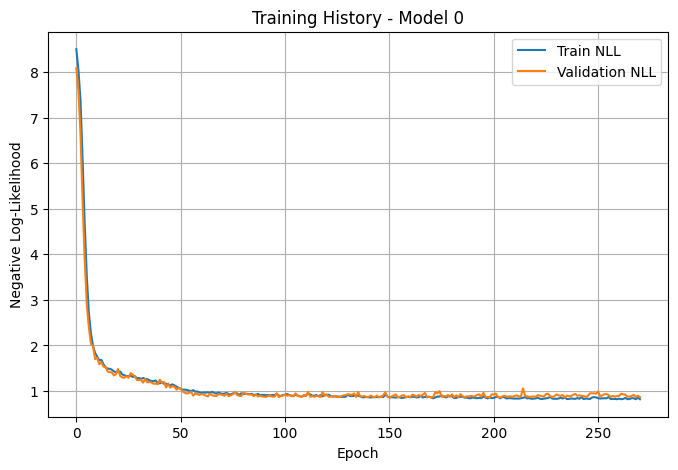

In [34]:
# Opción 1: Cargar el checkpoint específico del modelo que quieres ver
model_idx = 0
checkpoint_selected = torch.load(
    f'saved_models_validation/flow_selected_graph_{model_idx}.pt',
    map_location=torch.device('cpu'),
    weights_only=False
)

# Extraer el history
history = checkpoint_selected.get('history', None)

if history is not None:
    plt.figure(figsize=(8, 5))
    plt.plot(history['train_nll'], label='Train NLL')
    plt.plot(history['val_nll'], label='Validation NLL')
    plt.xlabel('Epoch')
    plt.ylabel('Negative Log-Likelihood')
    plt.title(f'Training History - Model {model_idx}')
    plt.legend()
    plt.grid()
    plt.show()
else:
    print("No history found in checkpoint")

# Interventions


In [46]:
def intervention_ate(
    flow_model,
    flow_gt,
    intervention_var,
    intervention_values,
    outcome_var,
    variables_selected,
    gt_variables,
    continuous_vars,
    scaler_selected,
    scaler_gt,
    test_size,
    verbose= False,
):
    """
    Compute ATE for an intervention on a variable for a given model and ground truth.

    Args:
        flow_model: Trained CausalNSF model for selected graph.
        flow_gt: Trained CausalNSF model for ground truth graph.
        intervention_var: Variable name to intervene on.
        intervention_values: List of two values for intervention.
        outcome_var: Variable name for outcome.
        variables_selected: Variable order for selected graph.
        gt_variables: Variable order for ground truth.
        continuous_vars: List of continuous variable names.
        scaler_selected: Scaler for selected graph.
        scaler_gt: Scaler for ground truth graph.
        test_size: Number of samples to generate.

    Returns:
        Dictionary with means and ATEs for selected and ground truth models.
    """
    # Only use ground truth variables that are present in the selected graph
    gt_vars_in_selected = [var for var in gt_variables if var in variables_selected]
    if outcome_var not in gt_vars_in_selected:
        raise ValueError(f"Outcome variable '{outcome_var}' not in selected graph variables.")

    intervention_index_selected = variables_selected.index(intervention_var)
    continuous_indices_selected = [variables_selected.index(c) for c in continuous_vars if c in variables_selected]

    intervention_index_gt = gt_variables.index(intervention_var)
    continuous_indices_gt = [gt_variables.index(c) for c in continuous_vars if c in gt_variables]

    outcome_index_gt = gt_vars_in_selected.index(outcome_var)

    # Selected graph: generate samples in its variable order
    samples_0_selected = flow_model().sample_interventional(
        index=intervention_index_selected,
        value=intervention_values[0],
        sample_shape=(test_size,),
    ).numpy()
    samples_1_selected = flow_model().sample_interventional(
        index=intervention_index_selected,
        value=intervention_values[1],
        sample_shape=(test_size,),
    ).numpy()

    # Denormalize using the scaler of the selected model
    samples_0_selected_denorm = samples_0_selected.copy()
    samples_1_selected_denorm = samples_1_selected.copy()
    if len(continuous_indices_selected) > 0:
        samples_0_selected_denorm[:, continuous_indices_selected] = scaler_selected.inverse_transform(
            samples_0_selected[:, continuous_indices_selected]
        )
        samples_1_selected_denorm[:, continuous_indices_selected] = scaler_selected.inverse_transform(
            samples_1_selected[:, continuous_indices_selected]
        )

    # Reorder only the variables present in both selected and ground truth
    reorder_indices = [variables_selected.index(var) for var in gt_vars_in_selected]
    samples_0_selected_denorm_gt = samples_0_selected_denorm[:, reorder_indices]
    samples_1_selected_denorm_gt = samples_1_selected_denorm[:, reorder_indices]

    # Ground truth: generate samples in its variable order
    samples_0_gt = flow_gt().sample_interventional(
        index=intervention_index_gt,
        value=intervention_values[0],
        sample_shape=(test_size,),
    ).numpy()
    samples_1_gt = flow_gt().sample_interventional(
        index=intervention_index_gt,
        value=intervention_values[1],
        sample_shape=(test_size,),
    ).numpy()

    # Denormalize using the scaler of the ground truth model
    samples_0_gt_denorm = samples_0_gt.copy()
    samples_1_gt_denorm = samples_1_gt.copy()
    if len(continuous_indices_gt) > 0:
        samples_0_gt_denorm[:, continuous_indices_gt] = scaler_gt.inverse_transform(
            samples_0_gt[:, continuous_indices_gt]
        )
        samples_1_gt_denorm[:, continuous_indices_gt] = scaler_gt.inverse_transform(
            samples_1_gt[:, continuous_indices_gt]
        )

    # Calculate means and ATE in the ground truth order (only for present variables)
    if outcome_var in continuous_vars:
        mean_0_selected = samples_0_selected_denorm_gt[:, outcome_index_gt].mean()
        mean_1_selected = samples_1_selected_denorm_gt[:, outcome_index_gt].mean()
        mean_0_gt = samples_0_gt_denorm[:, gt_variables.index(outcome_var)].mean()
        mean_1_gt = samples_1_gt_denorm[:, gt_variables.index(outcome_var)].mean()
    else:
        mean_0_selected = samples_0_selected_denorm_gt[:, outcome_index_gt].clip(0, 1).round().mean()
        mean_1_selected = samples_1_selected_denorm_gt[:, outcome_index_gt].clip(0, 1).round().mean()
        mean_0_gt = samples_0_gt_denorm[:, gt_variables.index(outcome_var)].clip(0, 1).round().mean()
        mean_1_gt = samples_1_gt_denorm[:, gt_variables.index(outcome_var)].clip(0, 1).round().mean()

    ate_selected = mean_1_selected - mean_0_selected
    ate_gt = mean_1_gt - mean_0_gt

    print(f"\nSelected Graph:")
    print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[0]:.2f})] = {mean_0_selected:.2f}")
    print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[1]:.2f})] = {mean_1_selected:.2f}")
    print(f"   ATE = {ate_selected:+.2f}")

    print(f"\nGround Truth Graph:")
    print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[0]:.2f})] = {mean_0_gt:.2f}")
    print(f"   E[{outcome_var} | do({intervention_var}={intervention_values[1]:.2f})] = {mean_1_gt:.2f}")
    print(f"   ATE = {ate_gt:+.2f}")

    print(f"\nDifference ATE:")
    if outcome_var in continuous_vars:
        print(f"   ATE_selected - ATE_gt= {abs(ate_selected - ate_gt):.2f}")
    else:
        print(f"   ATE_selected - ATE_gt = {abs(ate_selected - ate_gt):.1%}")

    return {
        "mean_0_selected": mean_0_selected,
        "mean_1_selected": mean_1_selected,
        "ate_selected": ate_selected,
        "mean_0_gt": mean_0_gt,
        "mean_1_gt": mean_1_gt,
        "ate_gt": ate_gt,
        "ate_diff": abs(ate_selected - ate_gt)
    }


## 1. Intervention on BMI and see effect in systolic pressure

In [17]:
scaler= scaler_gt
bmi_mean = scaler.mean_[1]
bmi_std = np.sqrt(scaler.var_[1])

intervention_var = 'bmi'  
intervention_index = gt_variables.index(intervention_var)

intervention_values = [24.0, 30.0]  # BMI low vs high, obesity vs non obesity
intervention_values = [float((val - bmi_mean) / bmi_std) for val in intervention_values]
intervention_values

outcome_var='systolic pressure'

### 1.1 Mean confidence interval  

In [67]:
import scipy.stats as stats

ate_selected_list = []
ate_gt_list = []

for model_dict in loaded_models:
    flow_selected = model_dict['flow_selected']
    variables_selected = model_dict['variables']
    scaler_selected = model_dict['scaler']
    scaler_gt = checkpoint_gt['scaler']
    gt_variables = checkpoint_gt['variables']

    # Run intervention for each model using the new function
    result = intervention_ate(
        flow_model=flow_selected,
        flow_gt=flow_gt,
        intervention_var=intervention_var,
        intervention_values=intervention_values,
        outcome_var=outcome_var,
        variables_selected=variables_selected,
        gt_variables=gt_variables,
        continuous_vars=continuous_vars,
        scaler_selected=scaler_selected,
        scaler_gt=scaler_gt,
        test_size=len(test_data)
    )
    ate_selected_list.append(result['ate_selected'])
    ate_gt_list.append(result['ate_gt'])

# Calculate mean and 95% confidence interval for selected graphs
ate_selected_array = np.array(ate_selected_list)
mean_ate_selected = ate_selected_array.mean()
conf_int_selected = stats.norm.interval(
    0.99,
    loc=mean_ate_selected,
    scale=stats.sem(ate_selected_array)
)

# Calculate mean and 95% confidence interval for ground truth
ate_gt_array = np.array(ate_gt_list)
mean_ate_gt = ate_gt_array.mean()
conf_int_gt = stats.norm.interval(
    0.99,
    loc=mean_ate_gt,
    scale=stats.sem(ate_gt_array)
)

print(f"\nMean ATE (selected graphs): {mean_ate_selected:.2f}")
print(f"95% Confidence Interval (selected): [{conf_int_selected[0]:.2f}, {conf_int_selected[1]:.2f}]")
print(f"\nMean ATE (ground truth): {mean_ate_gt:.2f}")
print(f"95% Confidence Interval (ground truth): [{conf_int_gt[0]:.2f}, {conf_int_gt[1]:.2f}]")



Selected Graph:
   E[systolic pressure | do(bmi=-0.45)] = 128.63
   E[systolic pressure | do(bmi=1.02)] = 136.01
   ATE = +7.38

Ground Truth Graph:
   E[systolic pressure | do(bmi=-0.45)] = 129.76
   E[systolic pressure | do(bmi=1.02)] = 137.76
   ATE = +8.00

Difference ATE:
   ATE_selected - ATE_gt= 0.61

Selected Graph:
   E[systolic pressure | do(bmi=-0.45)] = 129.44
   E[systolic pressure | do(bmi=1.02)] = 139.05
   ATE = +9.61

Ground Truth Graph:
   E[systolic pressure | do(bmi=-0.45)] = 128.49
   E[systolic pressure | do(bmi=1.02)] = 136.82
   ATE = +8.33

Difference ATE:
   ATE_selected - ATE_gt= 1.28

Selected Graph:
   E[systolic pressure | do(bmi=-0.45)] = 127.49
   E[systolic pressure | do(bmi=1.02)] = 136.33
   ATE = +8.85

Ground Truth Graph:
   E[systolic pressure | do(bmi=-0.45)] = 131.65
   E[systolic pressure | do(bmi=1.02)] = 138.16
   ATE = +6.51

Difference ATE:
   ATE_selected - ATE_gt= 2.34

Selected Graph:
   E[systolic pressure | do(bmi=-0.45)] = 128.66
   E

Mean Confidence Interval Function

In [18]:
def calculate_mean_confidence_interval(
    loaded_models,
    flow_gt,
    intervention_var,
    intervention_values,
    outcome_var,
    checkpoint_gt,
    continuous_vars,
    test_size,
    confidence_level=0.95
):
    """
    Calculate mean ATE confidence intervals for selected graphs and ground truth.
    
    Args:
        loaded_models: List of loaded model dictionaries
        flow_gt: Ground truth flow model
        intervention_var: Variable to intervene on
        intervention_values: List of intervention values [low, high]
        outcome_var: Outcome variable to measure
        checkpoint_gt: Ground truth graph 
        continuous_vars: List of continuous variable names
        test_size: Number of test samples
        confidence_level: Confidence level (default 0.95)
    
    Returns:
        Dictionary with means, confidence intervals, and arrays for both selected and GT
    """
    ate_selected_list = []
    ate_gt_list = []
    
    scaler_gt = checkpoint_gt['scaler']
    gt_variables = checkpoint_gt['variables']
    
    # Run interventions for all models
    for model_dict in loaded_models:
        flow_selected = model_dict['flow_selected']
        variables_selected = model_dict['variables']
        scaler_selected = model_dict['scaler']
        
        result = intervention_ate(
            flow_model=flow_selected,
            flow_gt=flow_gt,
            intervention_var=intervention_var,
            intervention_values=intervention_values,
            outcome_var=outcome_var,
            variables_selected=variables_selected,
            gt_variables=gt_variables,
            continuous_vars=continuous_vars,
            scaler_selected=scaler_selected,
            scaler_gt=scaler_gt,
            test_size=test_size
        )
        ate_selected_list.append(result['ate_selected'])
        ate_gt_list.append(result['ate_gt'])
    
    # Calculate statistics for selected graphs
    ate_selected_array = np.array(ate_selected_list)
    mean_ate_selected = ate_selected_array.mean()
    conf_int_selected = stats.norm.interval(
        confidence_level,
        loc=mean_ate_selected,
        scale=stats.sem(ate_selected_array)
    )
    
    # Calculate statistics for ground truth
    ate_gt_array = np.array(ate_gt_list)
    mean_ate_gt = ate_gt_array.mean()
    conf_int_gt = stats.norm.interval(
        confidence_level,
        loc=mean_ate_gt,
        scale=stats.sem(ate_gt_array)
    )
    
    # Print results
    print(f"\nMean ATE (selected graphs): {mean_ate_selected:.2f}")
    print(f"{int(confidence_level*100)}% Confidence Interval (selected): [{conf_int_selected[0]:.2f}, {conf_int_selected[1]:.2f}]")
    print(f"\nMean ATE (ground truth): {mean_ate_gt:.2f}")
    print(f"{int(confidence_level*100)}% Confidence Interval (ground truth): [{conf_int_gt[0]:.2f}, {conf_int_gt[1]:.2f}]")
    
    return {
        'ate_selected_array': ate_selected_array,
        'mean_ate_selected': mean_ate_selected,
        'conf_int_selected': conf_int_selected,
        'ate_gt_array': ate_gt_array,
        'mean_ate_gt': mean_ate_gt,
        'conf_int_gt': conf_int_gt
    }
# Example usage

results = calculate_mean_confidence_interval(
    loaded_models=loaded_models,
    flow_gt=flow_gt,
    intervention_var=intervention_var,
    intervention_values=intervention_values,
    outcome_var=outcome_var,
    checkpoint_gt=checkpoint_gt,
    continuous_vars=continuous_vars,
    test_size=len(test_data),
    confidence_level=0.95
)


Selected Graph:
   E[systolic pressure | do(bmi=-0.45)] = 130.69
   E[systolic pressure | do(bmi=1.02)] = 136.66
   ATE = +5.97

Ground Truth Graph:
   E[systolic pressure | do(bmi=-0.45)] = 128.79
   E[systolic pressure | do(bmi=1.02)] = 135.56
   ATE = +6.77

Difference ATE:
   ATE_selected - ATE_gt= 0.80

Selected Graph:
   E[systolic pressure | do(bmi=-0.45)] = 130.69
   E[systolic pressure | do(bmi=1.02)] = 137.52
   ATE = +6.83

Ground Truth Graph:
   E[systolic pressure | do(bmi=-0.45)] = 130.43
   E[systolic pressure | do(bmi=1.02)] = 138.57
   ATE = +8.14

Difference ATE:
   ATE_selected - ATE_gt= 1.31

Selected Graph:
   E[systolic pressure | do(bmi=-0.45)] = 130.41
   E[systolic pressure | do(bmi=1.02)] = 136.23
   ATE = +5.81

Ground Truth Graph:
   E[systolic pressure | do(bmi=-0.45)] = 130.27
   E[systolic pressure | do(bmi=1.02)] = 139.38
   ATE = +9.11

Difference ATE:
   ATE_selected - ATE_gt= 3.30

Selected Graph:
   E[systolic pressure | do(bmi=-0.45)] = 129.00
   E

### 1.2. Coverage interval Gaussian and Bootstrapping

In [12]:
# # if each individual ATE ground truth is within the prediction interval of selected graphs
def calculate_coverage_intervals(
    loaded_models,
    flow_gt,
    intervention_var,
    intervention_values,
    outcome_var,
    checkpoint_gt,
    continuous_vars,
    test_data
):
    """
    Calculate coverage intervals for ATE estimates from selected graphs.
    """

    ate_selected_list = []
    ate_gt_list = []
    skipped_models = 0

    for model_dict in loaded_models:
        flow_selected = model_dict['flow_selected']
        variables_selected = model_dict['variables']
        scaler_selected = model_dict['scaler']
        scaler_gt = checkpoint_gt['scaler']
        gt_variables = checkpoint_gt['variables']

        # Skip if intervention variable not in this graph
        if intervention_var not in variables_selected:
            skipped_models += 1
            continue
        
        # Skip if outcome variable not in this graph
        if outcome_var not in variables_selected:
            skipped_models += 1
            continue

        result = intervention_ate(
            flow_model=flow_selected,
            flow_gt=flow_gt,
            intervention_var=intervention_var,
            intervention_values=intervention_values,
            outcome_var=outcome_var,
            variables_selected=variables_selected,
            gt_variables=gt_variables,
            continuous_vars=continuous_vars,
            scaler_selected=scaler_selected,
            scaler_gt=scaler_gt,
            test_size=10000
        )
        ate_selected_list.append(result['ate_selected'])
        ate_gt_list.append(result['ate_gt'])

    if len(ate_selected_list) == 0:
        print(f"No models contained both '{intervention_var}' and '{outcome_var}'")
        return {
            'coverage_gaussian_95': np.nan,
            'coverage_bootstrap': np.nan,
            'skipped_models': skipped_models,
            'valid_models': 0
        }

    ate_gt_array = np.array(ate_gt_list)
    ate_selected_array = np.array(ate_selected_list)

    mean_ate_selected = ate_selected_array.mean()
    std_ate_selected = ate_selected_array.std()

    k_gaussian_95 = 1.96

    coverage_interval_gaussian_95 = (
        mean_ate_selected - k_gaussian_95 * std_ate_selected,
        mean_ate_selected + k_gaussian_95 * std_ate_selected
    )

    coverage_interval_bootstrap = (
        np.percentile(ate_selected_array, 2.5), # left bound
        np.percentile(ate_selected_array, 97.5) # right bound
    )

    # Check coverage for each individual GT ATE
    coverage_gaussian_95 = np.mean(
        (ate_gt_array >= coverage_interval_gaussian_95[0]) & 
        (ate_gt_array <= coverage_interval_gaussian_95[1])
    )

    coverage_bootstrap = np.mean(
        (ate_gt_array >= coverage_interval_bootstrap[0]) & 
        (ate_gt_array <= coverage_interval_bootstrap[1])
    )

    print("\nSelected Graphs ATE")
    print(f"Mean: {mean_ate_selected:.4f}, Std: {std_ate_selected:.4f}")
    print(f"Valid models: {len(ate_selected_array)} (skipped: {skipped_models})")

    print("\nPrediction Intervals from Selected Graphs")
    print(f"Gaussian 95%: [{coverage_interval_gaussian_95[0]:.4f}, {coverage_interval_gaussian_95[1]:.4f}]")
    print(f"Bootstrap 95%: [{coverage_interval_bootstrap[0]:.4f}, {coverage_interval_bootstrap[1]:.4f}]")

    print("\nCoverage Analysis Proportion of GT ATEs falling inside intervals")
    print(f"Gaussian 95%: {coverage_gaussian_95:.1%} of GT ATEs fall inside")
    print(f"Bootstrap 95%: {coverage_bootstrap:.1%} of GT ATEs fall inside")

    return {
        'coverage_gaussian_95': coverage_gaussian_95,
        'coverage_bootstrap': coverage_bootstrap,
        'skipped_models': skipped_models,
        'valid_models': len(ate_selected_array)
    }

with the 100 ground turth models

## 2. Intervention on age and see effect in diabetes mellitus 

In [76]:
scaler = scaler_gt

# Encuentra el índice de 'age' en continuous_vars (orden del scaler)
age_scaler_index = continuous_vars.index('age')

# Obtén media y std del scaler
age_mean = scaler.mean_[age_scaler_index]
age_std = np.sqrt(scaler.var_[age_scaler_index])

# Define la variable de intervención
intervention_var = 'age'  
intervention_index = gt_variables.index(intervention_var)

# Normaliza los valores de intervención
intervention_values = [40.0, 70.0]  # Age young vs old
intervention_values = [float((val - age_mean) / age_std) for val in intervention_values]
intervention_values

outcome_var = 'diabetes mellitus'
outcome_index = gt_variables.index(outcome_var)


In [28]:
import scipy.stats as stats
import numpy as np

ate_selected_list = []
ate_gt_list = []

for model_dict in loaded_models:
    flow_selected = model_dict['flow_selected']
    variables_selected = model_dict['variables']
    scaler_selected = model_dict['scaler']
    scaler_gt = checkpoint_gt['scaler']
    gt_variables = checkpoint_gt['variables']

    # Run intervention for each model using the new function
    result = intervention_ate(
        flow_model=flow_selected,
        flow_gt=flow_gt,
        intervention_var=intervention_var,
        intervention_values=intervention_values,
        outcome_var=outcome_var,
        variables_selected=variables_selected,
        gt_variables=gt_variables,
        continuous_vars=continuous_vars,
        scaler_selected=scaler_selected,
        scaler_gt=scaler_gt,
        test_size=len(test_data)
    )
    ate_selected_list.append(result['ate_selected'])
    ate_gt_list.append(result['ate_gt'])

# Bootstrap confidence interval function
def bootstrap_ci(data, n_bootstrap=1000, ci=0.99):
    means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        means.append(np.mean(sample))
    lower = np.percentile(means, (1-ci)/2*100)
    upper = np.percentile(means, (1+ci)/2*100)
    return lower, upper

# Calculate mean and bootstrap confidence interval for selected graphs
ate_selected_array = np.array(ate_selected_list)
mean_ate_selected = ate_selected_array.mean()
conf_int_selected = bootstrap_ci(ate_selected_array, n_bootstrap=1000, ci=0.95)

# Calculate mean and bootstrap confidence interval for ground truth
ate_gt_array = np.array(ate_gt_list)
mean_ate_gt = ate_gt_array.mean()
conf_int_gt = bootstrap_ci(ate_gt_array, n_bootstrap=1000, ci=0.95)

print(f"\nMean ATE (selected graphs): {mean_ate_selected:.2f}")
print(f"Bootstrap 99% Confidence Interval (selected): [{conf_int_selected[0]:.2f}, {conf_int_selected[1]:.2f}]")
print(f"\nMean ATE (ground truth): {mean_ate_gt:.2f}")
print(f"Bootstrap 99% Confidence Interval (ground truth): [{conf_int_gt[0]:.2f}, {conf_int_gt[1]:.2f}]")


Selected Graph:
   E[diabetes mellitus | do(age=-1.14)] = 0.01
   E[diabetes mellitus | do(age=2.31)] = 0.05
   ATE = +0.04

Ground Truth Graph:
   E[diabetes mellitus | do(age=-1.14)] = 0.01
   E[diabetes mellitus | do(age=2.31)] = 0.05
   ATE = +0.04

Difference ATE:
   ATE_selected - ATE_gt = 0.5%

Selected Graph:
   E[diabetes mellitus | do(age=-1.14)] = 0.02
   E[diabetes mellitus | do(age=2.31)] = 0.02
   ATE = +0.00

Ground Truth Graph:
   E[diabetes mellitus | do(age=-1.14)] = 0.02
   E[diabetes mellitus | do(age=2.31)] = 0.04
   ATE = +0.02

Difference ATE:
   ATE_selected - ATE_gt = 2.0%

Selected Graph:
   E[diabetes mellitus | do(age=-1.14)] = 0.02
   E[diabetes mellitus | do(age=2.31)] = 0.03
   ATE = +0.01

Ground Truth Graph:
   E[diabetes mellitus | do(age=-1.14)] = 0.01
   E[diabetes mellitus | do(age=2.31)] = 0.05
   ATE = +0.03

Difference ATE:
   ATE_selected - ATE_gt = 2.7%

Selected Graph:
   E[diabetes mellitus | do(age=-1.14)] = 0.03
   E[diabetes mellitus | do

coverage con bootstrapping

 en gaussiana media normal +- 3sigma
queremos ver donde donde caen las muestras este intervalo es distinro a la media

covergae gaussiana y coverage bootstraping las dos 
establecer una variable objetivo e ir interviniendo en todas
vector 1 o 0  si cae o no cae el valor dentro del intervalo


In [ ]:
# if each individual ATE ground truth is within the prediction interval of selected graphs
ate_selected_list = []
ate_gt_list = []

for model_dict in loaded_models:
    flow_selected = model_dict['flow_selected']
    variables_selected = model_dict['variables']
    scaler_selected = model_dict['scaler']
    scaler_gt = checkpoint_gt['scaler']
    gt_variables = checkpoint_gt['variables']

    result = intervention_ate(
        flow_model=flow_selected,
        flow_gt=flow_gt,
        intervention_var=intervention_var,
        intervention_values=intervention_values,
        outcome_var=outcome_var,
        variables_selected=variables_selected,
        gt_variables=gt_variables,
        continuous_vars=continuous_vars,
        scaler_selected=scaler_selected,
        scaler_gt=scaler_gt,
        test_size=len(test_data)
    )
    ate_selected_list.append(result['ate_selected'])
    ate_gt_list.append(result['ate_gt'])

ate_gt_array = np.array(ate_gt_list)
ate_selected_array = np.array(ate_selected_list)

mean_ate_selected = ate_selected_array.mean()
std_ate_selected = ate_selected_array.std()

k_gaussian_95 = 1.96

coverage_interval_gaussian_95 = (
    mean_ate_selected - k_gaussian_95 * std_ate_selected,
    mean_ate_selected + k_gaussian_95 * std_ate_selected
)

coverage_interval_bootstrap = (
    np.percentile(ate_selected_array, 2.5),
    np.percentile(ate_selected_array, 97.5)
)

# Check coverage for each individual GT ATE
coverage_gaussian_95 = np.mean(
    (ate_gt_array >= coverage_interval_gaussian_95[0]) & 
    (ate_gt_array <= coverage_interval_gaussian_95[1])
)

coverage_gaussian_997 = np.mean(
    (ate_gt_array >= coverage_interval_gaussian_997[0]) & 
    (ate_gt_array <= coverage_interval_gaussian_997[1])
)

coverage_bootstrap = np.mean(
    (ate_gt_array >= coverage_interval_bootstrap[0]) & 
    (ate_gt_array <= coverage_interval_bootstrap[1])
)

print("\nSelected Graphs ATE")
print(f"Mean: {mean_ate_selected:.4f}, Std: {std_ate_selected:.4f}")
print(f"Number of models: {len(ate_selected_array)}")

print("\nPrediction Intervals from Selected Graphs")
print(f"Gaussian 95%: [{coverage_interval_gaussian_95[0]:.4f}, {coverage_interval_gaussian_95[1]:.4f}]")
print(f"Bootstrap 95%: [{coverage_interval_bootstrap[0]:.4f}, {coverage_interval_bootstrap[1]:.4f}]")

print("\nCoverage Analysis: Proportion of GT ATEs falling inside intervals")
print(f"Gaussian 95%: {coverage_gaussian_95:.1%} of GT ATEs fall inside")
print(f"Bootstrap 95%: {coverage_bootstrap:.1%} of GT ATEs fall inside")


Selected Graph:
   E[diabetes mellitus | do(bmi=-0.45)] = 0.03
   E[diabetes mellitus | do(bmi=1.02)] = 0.04
   ATE = +0.01

Ground Truth Graph:
   E[diabetes mellitus | do(bmi=-0.45)] = 0.03
   E[diabetes mellitus | do(bmi=1.02)] = 0.04
   ATE = +0.01

Difference ATE:
   ATE_selected - ATE_gt = 0.5%

Selected Graph:
   E[diabetes mellitus | do(bmi=-0.45)] = 0.02
   E[diabetes mellitus | do(bmi=1.02)] = 0.05
   ATE = +0.02

Ground Truth Graph:
   E[diabetes mellitus | do(bmi=-0.45)] = 0.03
   E[diabetes mellitus | do(bmi=1.02)] = 0.05
   ATE = +0.02

Difference ATE:
   ATE_selected - ATE_gt = 0.9%

Selected Graph:
   E[diabetes mellitus | do(bmi=-0.45)] = 0.02
   E[diabetes mellitus | do(bmi=1.02)] = 0.04
   ATE = +0.02

Ground Truth Graph:
   E[diabetes mellitus | do(bmi=-0.45)] = 0.02
   E[diabetes mellitus | do(bmi=1.02)] = 0.04
   ATE = +0.02

Difference ATE:
   ATE_selected - ATE_gt = 0.0%

Selected Graph:
   E[diabetes mellitus | do(bmi=-0.45)] = 0.03
   E[diabetes mellitus | do

In [77]:
coverage_results2 = calculate_coverage_intervals(
    loaded_models=loaded_models,
    flow_gt=flow_gt,
    intervention_var=intervention_var,
    intervention_values=intervention_values,
    outcome_var=outcome_var,
    checkpoint_gt=checkpoint_gt,
    continuous_vars=continuous_vars,
    test_data=test_data
)


Selected Graph:
   E[diabetes mellitus | do(age=-1.14)] = 0.00
   E[diabetes mellitus | do(age=2.31)] = 0.07
   ATE = +0.07

Ground Truth Graph:
   E[diabetes mellitus | do(age=-1.14)] = 0.01
   E[diabetes mellitus | do(age=2.31)] = 0.06
   ATE = +0.05

Difference ATE:
   ATE_selected - ATE_gt = 2.0%

Selected Graph:
   E[diabetes mellitus | do(age=-1.14)] = 0.02
   E[diabetes mellitus | do(age=2.31)] = 0.02
   ATE = +0.01

Ground Truth Graph:
   E[diabetes mellitus | do(age=-1.14)] = 0.01
   E[diabetes mellitus | do(age=2.31)] = 0.03
   ATE = +0.03

Difference ATE:
   ATE_selected - ATE_gt = 2.0%

Selected Graph:
   E[diabetes mellitus | do(age=-1.14)] = 0.02
   E[diabetes mellitus | do(age=2.31)] = 0.02
   ATE = +0.00

Ground Truth Graph:
   E[diabetes mellitus | do(age=-1.14)] = 0.00
   E[diabetes mellitus | do(age=2.31)] = 0.04
   ATE = +0.03

Difference ATE:
   ATE_selected - ATE_gt = 3.2%

Selected Graph:
   E[diabetes mellitus | do(age=-1.14)] = 0.02
   E[diabetes mellitus | do

## 3. Intervention: Establish one target variable and intervene on all other variables

In [ ]:
# Define target variable
target_var = 'major acute cardiovascular event'

# Get all variables except the target
intervention_vars = [var for var in gt_variables if var != target_var]

# Storage for results
all_coverage_results = {}

# Define intervention values for each variable
def get_intervention_values(var_name, scaler_gt, continuous_vars, gt_variables):
    """
    Get appropriate intervention values for a variable.
    
    Args:
        var_name: Name of the variable
        scaler_gt: Ground truth scaler
        continuous_vars: List of continuous variable names
        gt_variables: List of all ground truth variables
    
    Returns:
        List of two intervention values [low, high]
    """
    if var_name in continuous_vars:
        # For continuous variables, use scaler statistics
        scaler_index = continuous_vars.index(var_name)
        var_mean = scaler_gt.mean_[scaler_index]
        var_std = np.sqrt(scaler_gt.var_[scaler_index])
        
        # Define intervention ranges based on variable type
        if var_name == 'age':
            raw_values = [40.0, 70.0]  # Young vs old
        elif var_name == 'bmi':
            raw_values = [24.0, 30.0]  # Normal vs obese
        elif var_name == 'systolic pressure':
            raw_values = [110.0, 140.0]  # Normal vs high
        elif var_name == 'diastolic pressure':
            raw_values = [70.0, 90.0]  # Normal vs high
        else:
            # Generic: mean ± 1.5 std
            raw_values = [var_mean - 1.5 * var_std, var_mean + 1.5 * var_std]
        
        # Normalize values
        normalized_values = [float((val - var_mean) / var_std) for val in raw_values]
        return normalized_values
    else:
        # For binary variables (cardiac ischemia, diabetes mellitus)
        return [0.0, 1.0]

# Loop through all intervention variables
print(f"TARGET OUTCOME: {target_var}")
print(f"Running interventions on {len(intervention_vars)} variables")

for intervention_var in tqdm(intervention_vars, desc="Processing interventions"):
    print(f"Intervention: {intervention_var} → Outcome: {target_var}")
    
    # Get intervention values
    intervention_values = get_intervention_values(
        intervention_var, 
        scaler_gt, 
        continuous_vars, 
        gt_variables
    )
    
    var_type = "continuous" if intervention_var in continuous_vars else "binary"
    print(f"Variable type: {var_type}")
    print(f"Intervention values: {intervention_values}")
    
    # Calculate coverage intervals
    coverage_results = calculate_coverage_intervals(
        loaded_models=loaded_models,
        flow_gt=flow_gt,
        intervention_var=intervention_var,
        intervention_values=intervention_values,
        outcome_var=target_var,
        checkpoint_gt=checkpoint_gt,
        continuous_vars=continuous_vars,
        test_data=test_data
    )
    
    # Store results with all fields from coverage_results
    all_coverage_results[intervention_var] = {
        'variable_type': var_type,
        'intervention_values': intervention_values,
        'coverage_gaussian_95': coverage_results['coverage_gaussian_95'],
        'coverage_bootstrap': coverage_results['coverage_bootstrap'],
        'valid_models': coverage_results['valid_models'],
        'skipped_models': coverage_results['skipped_models']
    }

# Create summary DataFrame
summary_data = []
for var, results in all_coverage_results.items():
    if results['variable_type'] == 'continuous':
        interv_str = f"{results['intervention_values'][0]:.2f} → {results['intervention_values'][1]:.2f}"
    else:
        interv_str = "0 → 1"
    
    # Handle NaN values
    cov_gauss = results['coverage_gaussian_95']
    cov_boot = results['coverage_bootstrap']
    
    summary_data.append({
        'Intervention Variable': var,
        'Type': results['variable_type'],
        'Intervention Values': interv_str,
        'Coverage Gaussian 95%': f"{cov_gauss:.1%}" if not np.isnan(cov_gauss) else "N/A",
        'Coverage Bootstrap 95%': f"{cov_boot:.1%}" if not np.isnan(cov_boot) else "N/A",
        'Valid Models': results.get('valid_models', 'N/A'),
        'Skipped Models': results.get('skipped_models', 'N/A')
    })

summary_df = pd.DataFrame(summary_data)

In [ ]:
print(f"SUMMARY: All interventions → '{target_var}'")
print(summary_df.to_string(index=False))

# Calculate average coverage (excluding NaN values)
valid_results = [r for r in all_coverage_results.values() 
                if not np.isnan(r['coverage_gaussian_95'])]

avg_coverage_gaussian = np.mean([r['coverage_gaussian_95'] for r in valid_results])
avg_coverage_bootstrap = np.mean([r['coverage_bootstrap'] for r in valid_results])

print(f"AVERAGE COVERAGE ACROSS ALL INTERVENTIONS")
print(f"Gaussian 95%:   {avg_coverage_gaussian:.1%}")
print(f"Bootstrap 95%:  {avg_coverage_bootstrap:.1%}")
print(f"Valid interventions: {len(valid_results)}/{len(all_coverage_results)}")

SUMMARY: All interventions → 'major acute cardiovascular event'
Intervention Variable       Type Intervention Values Coverage Gaussian 95% Coverage Bootstrap 95%  Valid Models  Skipped Models
                  age continuous        -1.14 → 2.31                100.0%                 100.0%           100               0
                  bmi continuous        -0.45 → 1.02                 95.0%                  95.0%           100               0
    diabetes mellitus     binary               0 → 1                100.0%                 100.0%           100               0
     cardiac ischemia     binary               0 → 1                100.0%                  73.7%            99               1
   diastolic pressure continuous        -1.09 → 0.57                100.0%                 100.0%           100               0
    systolic pressure continuous        -1.03 → 0.31                100.0%                  99.0%           100               0
AVERAGE COVERAGE ACROSS ALL INTERVENTION

### 4. Interventions all

In [47]:

def get_intervention_values(var_name, scaler_gt, continuous_vars, gt_variables):
    """Get intervention values for a variable."""
    if var_name in continuous_vars:
        scaler_index = continuous_vars.index(var_name)
        var_mean = scaler_gt.mean_[scaler_index]
        var_std = np.sqrt(scaler_gt.var_[scaler_index])
        
        # Define intervention ranges
        interventions = {
            'age': [40.0, 70.0],
            'bmi': [24.0, 30.0],
            'systolic pressure': [110.0, 140.0],
            'diastolic pressure': [70.0, 90.0]
        }
        raw_values = interventions.get(var_name, [var_mean - 1.5 * var_std, var_mean + 1.5 * var_std])
        return [float((val - var_mean) / var_std) for val in raw_values]
    else:
        return [0.0, 1.0]

In [ ]:
# Main loop
all_targets_results = {}

for target_var in tqdm(gt_variables, desc="Processing targets"):
    intervention_vars = [var for var in gt_variables if var != target_var]
    target_coverage_results = {}
    
    for intervention_var in tqdm(intervention_vars, desc=f"{target_var}", leave=False):
        intervention_values = get_intervention_values(intervention_var, scaler_gt, continuous_vars, gt_variables)
        
        coverage_results = calculate_coverage_intervals(
            loaded_models=loaded_models,
            flow_gt=flow_gt,
            intervention_var=intervention_var,
            intervention_values=intervention_values,
            outcome_var=target_var,
            checkpoint_gt=checkpoint_gt,
            continuous_vars=continuous_vars,
            test_data=10000
        )
        
        target_coverage_results[intervention_var] = {
            'variable_type': "continuous" if intervention_var in continuous_vars else "binary",
            'intervention_values': intervention_values,
            **coverage_results
        }
    
    all_targets_results[target_var] = target_coverage_results

In [23]:
rows = []
for target_var, interventions in all_targets_results.items():
    for intervention_var, results in interventions.items():
        rows.append({
            'Target Variable': target_var,
            'Target Type': 'continuous' if target_var in continuous_vars else 'binary',
            'Intervention Variable': intervention_var,
            'Intervention Type': results['variable_type'],
            'Intervention Low': results['intervention_values'][0],
            'Intervention High': results['intervention_values'][1],
            'Coverage Gaussian 95%': results['coverage_gaussian_95'],
            'Coverage Bootstrap 95%': results['coverage_bootstrap'],
            'Valid Models': results['valid_models'],
            'Skipped Models': results['skipped_models']
        })

# Create comprehensive DataFrame
df_all_interventions = pd.DataFrame(rows)
df_all_interventions

,Target Variable,Target Type,Intervention Variable,Intervention Type,Intervention Low,Intervention High,Coverage Gaussian 95%,Coverage Bootstrap 95%,Valid Models,Skipped Models
0,age,continuous,bmi,continuous,-0.449020,1.015528,0.980000,0.980000,100,0
1,age,continuous,diabetes mellitus,binary,0.000000,1.000000,0.960000,0.970000,100,0
2,age,continuous,cardiac ischemia,binary,0.000000,1.000000,0.949495,0.939394,99,1
3,age,continuous,diastolic pressure,continuous,-1.092456,0.567284,0.970000,0.970000,100,0
4,age,continuous,systolic pressure,continuous,-1.026206,0.312048,0.950000,0.970000,100,0
5,age,continuous,major acute cardiovascular event,binary,0.000000,1.000000,0.930000,0.940000,100,0
6,bmi,continuous,age,continuous,-1.144059,2.313775,1.000000,0.030000,100,0
7,bmi,continuous,diabetes mellitus,binary,0.000000,1.000000,0.920000,0.920000,100,0
8,bmi,continuous,cardiac ischemia,binary,0.000000,1.000000,0.939394,0.919192,99,1
9,bmi,continuous,diastolic pressure,continuous,-1.092456,0.567284,0.980000,0.940000,100,0


In [24]:
# Save to CSV
df_all_interventions.to_csv('df_all_interventions_1modelgt.csv', index=False)

figura crear 
media varianza box plot media y varianza

especificar que estos resultados son buenos en este dataset, pero se podria probar en otro context
linea futura, limitaciones : comparar con otros datasets

promedio coverage por variable de output 
promedio 
skipped models en la memoria 1 

Notes

we could also do if the mean ATE ground truth is within the prediction interval of selected graphs

Comparing Means vs. Distributions
we are checking if one mean (GT) falls within the prediction interval of another distribution (selected graphs). Can we do this?

 Does mean(GT) fall within prediction_interval(selected)? ->  Gaussian prediction interval assumes normality of individual ATEs. But we have:100 models with different graph structures Each produces one ATE estimate
This is not the same as sampling from a single distribution

bootstraping percentiles intervals make more sense
What makes more sense: Does the GT distribution overlap with the selected distribution?

### Compare with no graph model

In [2]:
# Load the model without graph structure
checkpoint_no_graph = torch.load(
    'saved_models_validation/flow_no_graph.pt',
    map_location=torch.device('cpu'),
    weights_only=False
)

flow_no_graph = CausalNSF(
    checkpoint_no_graph['features'],
    0,
    order=checkpoint_no_graph['order'],
    hidden_features=checkpoint_no_graph['config']['hidden_dims']
)
flow_no_graph.load_state_dict(checkpoint_no_graph['model_state_dict'])
flow_no_graph.eval()

scaler_no_graph = checkpoint_no_graph['scaler']
variables_no_graph = checkpoint_no_graph['variables']

print(f"Loaded no-graph model")

Loaded no-graph model


In [ ]:
scaler= scaler_gt
bmi_mean = scaler.mean_[1]
bmi_std = np.sqrt(scaler.var_[1])

intervention_var = 'bmi'  
intervention_index = gt_variables.index(intervention_var)

intervention_values = [24.0, 30.0]  # BMI low vs high, obesity vs non obesity
intervention_values = [float((val - bmi_mean) / bmi_std) for val in intervention_values]
intervention_values

outcome_var='systolic pressure'

In [22]:
ate_selected_list = []
ate_gt_list = []

result = intervention_ate(
    flow_model=flow_no_graph,
    flow_gt=flow_gt,
    intervention_var=intervention_var,
    intervention_values=intervention_values,
    outcome_var=outcome_var,
    variables_selected=variables_no_graph,
    gt_variables=gt_variables,
    continuous_vars=continuous_vars,
    scaler_selected=scaler_no_graph,
    scaler_gt=scaler_gt,
    test_size=len(test_data)
)
ate_selected_list.append(result['ate_selected'])
ate_gt_list.append(result['ate_gt'])


Selected Graph:
   E[systolic pressure | do(bmi=-0.45)] = 131.42
   E[systolic pressure | do(bmi=1.02)] = 140.89
   ATE = +9.47

Ground Truth Graph:
   E[systolic pressure | do(bmi=-0.45)] = 129.85
   E[systolic pressure | do(bmi=1.02)] = 137.55
   ATE = +7.70

Difference ATE:
   ATE_selected - ATE_gt= 1.77


## Interventions all with no graph

In [ ]:
# Create 100 references to the same no-graph model
no_graph_models = []
for i in range(100):
    no_graph_models.append({
        'flow_selected': flow_no_graph,
        'variables': variables_no_graph,
        'scaler': scaler_no_graph
    })

print(f"Imported {len(no_graph_models)} no-graph model instances for sampling")

Created 100 no-graph model instances for sampling


In [ ]:
# Run the same intervention analysis with no-graph model (100 samples)
all_targets_results_no_graph = {}

for target_var in tqdm(gt_variables, desc="Processing targets (no-graph)"):
    intervention_vars = [var for var in gt_variables if var != target_var]
    target_coverage_results = {}
    
    for intervention_var in tqdm(intervention_vars, desc=f"{target_var}", leave=False):
        intervention_values = get_intervention_values(
            intervention_var, scaler_gt, continuous_vars, gt_variables
        )
        
        coverage_results = calculate_coverage_intervals(
            loaded_models=no_graph_models,
            flow_gt=flow_gt,
            intervention_var=intervention_var,
            intervention_values=intervention_values,
            outcome_var=target_var,
            checkpoint_gt=checkpoint_gt,
            continuous_vars=continuous_vars,
            test_data=10000
        )
        
        target_coverage_results[intervention_var] = {
            'variable_type': "continuous" if intervention_var in continuous_vars else "binary",
            'intervention_values': intervention_values,
            **coverage_results
        }
    
    all_targets_results_no_graph[target_var] = target_coverage_results

# Create DataFrame for no-graph results
rows_no_graph = []
for target_var, interventions in all_targets_results_no_graph.items():
    for intervention_var, results in interventions.items():
        rows_no_graph.append({
            'Target Variable': target_var,
            'Target Type': 'continuous' if target_var in continuous_vars else 'binary',
            'Intervention Variable': intervention_var,
            'Intervention Type': results['variable_type'],
            'Intervention Low': results['intervention_values'][0],
            'Intervention High': results['intervention_values'][1],
            'Coverage Gaussian 95%': results['coverage_gaussian_95'],
            'Coverage Bootstrap 95%': results['coverage_bootstrap'],
            'Valid Models': results['valid_models'],
            'Skipped Models': results['skipped_models']
        })

df_no_graph_interventions = pd.DataFrame(rows_no_graph)
df_no_graph_interventions

In [19]:
#save to csv
# Save to CSV
df_no_graph_interventions.to_csv('no_graph_interventions_coverage.csv', index=False)

In [25]:
# Calculate average coverage for knowledge graph models
valid_kg = [r for target in all_targets_results.values() 
            for r in target.values() 
            if not np.isnan(r['coverage_gaussian_95'])]

avg_cov_kg_gauss = np.mean([r['coverage_gaussian_95'] for r in valid_kg])
avg_cov_kg_boot = np.mean([r['coverage_bootstrap'] for r in valid_kg])

# Calculate average coverage for no-graph model
valid_ng = [r for target in all_targets_results_no_graph.values() 
            for r in target.values() 
            if not np.isnan(r['coverage_gaussian_95'])]

avg_cov_ng_gauss = np.mean([r['coverage_gaussian_95'] for r in valid_ng])
avg_cov_ng_boot = np.mean([r['coverage_bootstrap'] for r in valid_ng])

print(f"\nKNOWLEDGE GRAPH ESTIMATED MODELS")
print(f"  Average Gaussian Coverage:   {avg_cov_kg_gauss:.1%}")
print(f"  Average Bootstrap Coverage:  {avg_cov_kg_boot:.1%}")

print(f"\nNO-GRAPH MODEL")
print(f"  Average Gaussian Coverage:   {avg_cov_ng_gauss:.1%}")
print(f"  Average Bootstrap Coverage:  {avg_cov_ng_boot:.1%}")



KNOWLEDGE GRAPH ESTIMATED MODELS
  Average Gaussian Coverage:   92.2%
  Average Bootstrap Coverage:  89.3%

NO-GRAPH MODEL
  Average Gaussian Coverage:   61.5%
  Average Bootstrap Coverage:  60.6%


In [ ]:
summary_coverage = pd.DataFrame({
    'Model Type': ['Knowledge Graph Models', 'No-Graph Model'],
    'Average Gaussian Coverage (%)': [avg_cov_kg_gauss * 100, avg_cov_ng_gauss * 100],
    'Average Bootstrap Coverage (%)': [avg_cov_kg_boot * 100, avg_cov_ng_boot * 100]
})

# Save to CSV
summary_coverage.to_csv('average_coverage_comparison_1modelgt_1model_nograph.csv', index=False)

print("\nSaved coverage comparison to CSV")
summary_coverage

,Model Type,Average Gaussian Coverage (%),Average Bootstrap Coverage (%)
0,Knowledge Graph Models,92.2,89.3
1,No-Graph Model,61.5,60.6


### 100 graphs ALL ground truth and no graphstructure models

Import 100 ground truth models

In [13]:
# Load all ground truth models
loaded_models_ground_truth = []

for graph_idx in range(100):
    # Load ground truth model
    checkpoint_gt = torch.load(
        f'saved_models_ground_truth/flow_ground_truth_{graph_idx}.pt',
        map_location=torch.device('cpu'),
        weights_only=False  
    )
    flow_gt = CausalNSF(
        checkpoint_gt['features'],
        0,
        adjacency=checkpoint_gt['adjacency'],
        hidden_features=checkpoint_gt['config']['hidden_dims']
    )
    flow_gt.load_state_dict(checkpoint_gt['model_state_dict'])
    flow_gt.eval()
    
    loaded_models_ground_truth.append({
        'flow_gt': flow_gt,
        'variables': checkpoint_gt['variables'],
        'scaler': checkpoint_gt['scaler'], 
    })

print(f"Loaded {len(loaded_models_ground_truth)} ground truth models")

Loaded 100 ground truth models


Import 100 no graph modles with random order in training

In [14]:
# Load all no-graph models
loaded_models_no_graph = []

for graph_idx in range(100):
    # Load no-graph model
    checkpoint_no_graph = torch.load(
        f'saved_models_no_graph/flow_no_graph{graph_idx}.pt',
        map_location=torch.device('cpu'),
        weights_only=False  
    )
    flow_no_graph = CausalNSF(
        checkpoint_no_graph['features'],
        0,
        order=checkpoint_no_graph['order'],
        hidden_features=checkpoint_no_graph['config']['hidden_dims']
    )
    flow_no_graph.load_state_dict(checkpoint_no_graph['model_state_dict'])
    flow_no_graph.eval()
    
    loaded_models_no_graph.append({
        'flow_no_graph': flow_no_graph,
        'variables': checkpoint_no_graph['variables'],
        'scaler': checkpoint_no_graph['scaler'], 
    })

print(f"Loaded {len(loaded_models_no_graph)} no-graph models")

Loaded 100 no-graph models


Import 100 no-graph models trained with ground truth  order

In [15]:
# Load all no-graph models
loaded_models_no_graph_gt_order = []

for graph_idx in range(100):
    # Load no-graph model
    checkpoint_no_graph = torch.load(
        f'saved_models_no_graph_gt_order/flow_no_graph{graph_idx}.pt',
        map_location=torch.device('cpu'),
        weights_only=False  
    )
    flow_no_graph = CausalNSF(
        checkpoint_no_graph['features'],
        0,
        order=checkpoint_no_graph['order'],
        hidden_features=checkpoint_no_graph['config']['hidden_dims']
    )
    flow_no_graph.load_state_dict(checkpoint_no_graph['model_state_dict'])
    flow_no_graph.eval()
    
    loaded_models_no_graph_gt_order.append({
        'flow_no_graph': flow_no_graph,
        'variables': checkpoint_no_graph['variables'],
        'scaler': checkpoint_no_graph['scaler'], 
    })

print(f"Loaded {len(loaded_models_no_graph_gt_order)} no-graph models")

Loaded 100 no-graph models


Function

In [34]:
def calculate_coverage_intervals_100(
    loaded_models,
    flow_gt_models,  # Now a list of GT model dictionaries
    intervention_var,
    intervention_values,
    outcome_var,
    continuous_vars,
    test_size=10000
):
    """
    Calculate coverage intervals for ATE estimates from selected graphs.
    Pairs each selected model with its corresponding ground truth model.
    """

    ate_selected_list = []
    ate_gt_list = []
    skipped_models = 0

    # Iterate through both lists simultaneously
    for model_dict, gt_model_dict in zip(loaded_models, flow_gt_models):
        # Extract from selected/no-graph model
        flow_selected = model_dict.get('flow_selected') or model_dict.get('flow_no_graph')
        variables_selected = model_dict['variables']
        scaler_selected = model_dict['scaler']
        
        # Extract from paired ground truth model
        flow_gt = gt_model_dict['flow_gt']
        scaler_gt = gt_model_dict['scaler']  # Each GT has its own scaler!
        gt_variables = gt_model_dict['variables']  # Same across all, but keep consistent

        # Skip if intervention variable not in this graph
        if intervention_var not in variables_selected:
            skipped_models += 1
            continue
        
        # Skip if outcome variable not in this graph
        if outcome_var not in variables_selected:
            skipped_models += 1
            continue

        result = intervention_ate(
            flow_model=flow_selected,
            flow_gt=flow_gt,  # Using the paired GT model
            intervention_var=intervention_var,
            intervention_values=intervention_values,
            outcome_var=outcome_var,
            variables_selected=variables_selected,
            gt_variables=gt_variables,
            continuous_vars=continuous_vars,
            scaler_selected=scaler_selected,
            scaler_gt=scaler_gt,  # Using paired GT's scaler
            test_size=test_size
        )
        ate_selected_list.append(result['ate_selected'])
        ate_gt_list.append(result['ate_gt'])

    if len(ate_selected_list) == 0:
        print(f"No models contained both '{intervention_var}' and '{outcome_var}'")
        return {
            'coverage_gaussian_95': np.nan,
            'coverage_bootstrap': np.nan,
            'skipped_models': skipped_models,
            'valid_models': 0
        }

    ate_gt_array = np.array(ate_gt_list)
    ate_selected_array = np.array(ate_selected_list)

    mean_ate_selected = ate_selected_array.mean()
    std_ate_selected = ate_selected_array.std()

    k_gaussian_95 = 1.96

    coverage_interval_gaussian_95 = (
        mean_ate_selected - k_gaussian_95 * std_ate_selected,
        mean_ate_selected + k_gaussian_95 * std_ate_selected
    )

    coverage_interval_bootstrap = (
        np.percentile(ate_selected_array, 2.5),
        np.percentile(ate_selected_array, 97.5)
    )

    coverage_gaussian_95 = np.mean(
        (ate_gt_array >= coverage_interval_gaussian_95[0]) & 
        (ate_gt_array <= coverage_interval_gaussian_95[1])
    )

    coverage_bootstrap = np.mean(
        (ate_gt_array >= coverage_interval_bootstrap[0]) & 
        (ate_gt_array <= coverage_interval_bootstrap[1])
    )

    print("\nKnowledge Graph Models ATE")
    print(f"Mean: {mean_ate_selected:.4f}, Std: {std_ate_selected:.4f}")
    print(f"Valid models: {len(ate_selected_array)} (skipped: {skipped_models})")

    print("\nPrediction Intervals from Knowledge Graph Models")
    print(f"Gaussian 95%: [{coverage_interval_gaussian_95[0]:.4f}, {coverage_interval_gaussian_95[1]:.4f}]")
    print(f"Bootstrap 95%: [{coverage_interval_bootstrap[0]:.4f}, {coverage_interval_bootstrap[1]:.4f}]")

    print("\nCoverage Analysis: Proportion of GT ATEs falling inside intervals")
    print(f"Gaussian 95%: {coverage_gaussian_95:.1%} of GT ATEs fall inside")
    print(f"Bootstrap 95%: {coverage_bootstrap:.1%} of GT ATEs fall inside")

    return {
        'coverage_gaussian_95': coverage_gaussian_95,
        'coverage_bootstrap': coverage_bootstrap,
        'skipped_models': skipped_models,
        'valid_models': len(ate_selected_array)
    }


### Main loop for knowledge graph models vs ground truth models

In [ ]:
all_targets_results_kg = {}

for target_var in tqdm(gt_variables, desc="Processing targets (KG vs GT)"):
    intervention_vars = [var for var in gt_variables if var != target_var]
    target_coverage_results = {}
    
    for intervention_var in tqdm(intervention_vars, desc=f"{target_var}", leave=False):
        intervention_values = get_intervention_values(
            intervention_var, scaler_gt, continuous_vars, gt_variables
        )
        
        coverage_results = calculate_coverage_intervals_100(
            loaded_models=loaded_models,
            flow_gt_models=loaded_models_ground_truth,
            intervention_var=intervention_var,
            intervention_values=intervention_values,
            outcome_var=target_var,
            continuous_vars=continuous_vars,
            test_size=10000
        )
        
        target_coverage_results[intervention_var] = {
            'variable_type': "continuous" if intervention_var in continuous_vars else "binary",
            'intervention_values': intervention_values,
            **coverage_results
        }
    
    all_targets_results_kg[target_var] = target_coverage_results

rows_kg = []
for target_var, interventions in all_targets_results_kg.items():
    for intervention_var, results in interventions.items():
        rows_kg.append({
            'Target Variable': target_var,
            'Target Type': 'continuous' if target_var in continuous_vars else 'binary',
            'Intervention Variable': intervention_var,
            'Intervention Type': results['variable_type'],
            'Intervention Low': results['intervention_values'][0],
            'Intervention High': results['intervention_values'][1],
            'Coverage Gaussian 95%': results['coverage_gaussian_95'],
            'Coverage Bootstrap 95%': results['coverage_bootstrap'],
            'Valid Models': results['valid_models'],
            'Skipped Models': results['skipped_models']
        })

df_kg_interventions = pd.DataFrame(rows_kg)


In [18]:
df_kg_interventions.to_csv('kg_interventions_coverage_100_models_all.csv', index=False)

### Main loop for NO graph RANDOM ORDER models vs ground truth models

In [ ]:
# Main loop for no-graph models vs ground truth models
all_targets_results_no_graph_100 = {}

for target_var in tqdm(gt_variables, desc="Processing targets (No-Graph vs GT)"):
    intervention_vars = [var for var in gt_variables if var != target_var]
    target_coverage_results = {}
    
    for intervention_var in tqdm(intervention_vars, desc=f"{target_var}", leave=False):
        intervention_values = get_intervention_values(
            intervention_var, scaler_gt, continuous_vars, gt_variables
        )
        
        coverage_results = calculate_coverage_intervals_100(
            loaded_models=loaded_models_no_graph,  # Use no-graph models
            flow_gt_models=loaded_models_ground_truth,  # Paired GT models
            intervention_var=intervention_var,
            intervention_values=intervention_values,
            outcome_var=target_var,
            continuous_vars=continuous_vars,
            test_size=1000
        )
        
        target_coverage_results[intervention_var] = {
            'variable_type': "continuous" if intervention_var in continuous_vars else "binary",
            'intervention_values': intervention_values,
            **coverage_results
        }
    
    all_targets_results_no_graph_100[target_var] = target_coverage_results

# Create DataFrame for no-graph vs GT results
rows_no_graph_100 = []
for target_var, interventions in all_targets_results_no_graph_100.items():
    for intervention_var, results in interventions.items():
        rows_no_graph_100.append({
            'Target Variable': target_var,
            'Target Type': 'continuous' if target_var in continuous_vars else 'binary',
            'Intervention Variable': intervention_var,
            'Intervention Type': results['variable_type'],
            'Intervention Low': results['intervention_values'][0],
            'Intervention High': results['intervention_values'][1],
            'Coverage Gaussian 95%': results['coverage_gaussian_95'],
            'Coverage Bootstrap 95%': results['coverage_bootstrap'],
            'Valid Models': results['valid_models'],
            'Skipped Models': results['skipped_models']
        })

df_no_graph_interventions_100_random = pd.DataFrame(rows_no_graph_100)

#df_no_graph_interventions_100_random.to_csv('no_graph_interventions_coverage_100_models_rando2.csv', index=False)

In [37]:
df_no_graph_interventions_100_random

,Target Variable,Target Type,Intervention Variable,Intervention Type,Intervention Low,Intervention High,Coverage Gaussian 95%,Coverage Bootstrap 95%,Valid Models,Skipped Models
0,age,continuous,bmi,continuous,-0.449020,1.015528,1.00,0.98,100,0
1,age,continuous,diabetes mellitus,binary,0.000000,1.000000,1.00,0.98,100,0
2,age,continuous,cardiac ischemia,binary,0.000000,1.000000,1.00,0.98,100,0
3,age,continuous,diastolic pressure,continuous,-1.092456,0.567284,1.00,1.00,100,0
4,age,continuous,systolic pressure,continuous,-1.026206,0.312048,1.00,0.95,100,0
5,age,continuous,major acute cardiovascular event,binary,0.000000,1.000000,1.00,0.94,100,0
6,bmi,continuous,age,continuous,-1.144059,2.313775,0.54,0.53,100,0
7,bmi,continuous,diabetes mellitus,binary,0.000000,1.000000,1.00,0.97,100,0
8,bmi,continuous,cardiac ischemia,binary,0.000000,1.000000,1.00,0.93,100,0
9,bmi,continuous,diastolic pressure,continuous,-1.092456,0.567284,1.00,0.93,100,0


### Summary results

In [19]:
def create_summary_coverage(
    all_targets_results_kg,
    all_targets_results_no_graph,
    save_path=None
):
    """
    Create summary coverage comparison between KG models and no-graph models.
    
    Args:
        all_targets_results_kg: Dictionary with coverage results from KG models
        all_targets_results_no_graph: Dictionary with coverage results from no-graph models
        save_path: Optional path to save CSV file
    
    Returns:
        DataFrame with summary coverage statistics
    """
    # Calculate average coverage for knowledge graph models
    valid_kg = [r for target in all_targets_results_kg.values() 
                for r in target.values() 
                if not np.isnan(r['coverage_gaussian_95'])]
    
    avg_cov_kg_gauss = np.mean([r['coverage_gaussian_95'] for r in valid_kg])
    avg_cov_kg_boot = np.mean([r['coverage_bootstrap'] for r in valid_kg])
    
    # Calculate average coverage for no-graph model
    valid_ng = [r for target in all_targets_results_no_graph.values() 
                for r in target.values() 
                if not np.isnan(r['coverage_gaussian_95'])]
    
    avg_cov_ng_gauss = np.mean([r['coverage_gaussian_95'] for r in valid_ng])
    avg_cov_ng_boot = np.mean([r['coverage_bootstrap'] for r in valid_ng])
    
    # Print results
    print(f"\nKNOWLEDGE GRAPH ESTIMATED MODELS")
    print(f"  Average Gaussian Coverage:   {avg_cov_kg_gauss:.1%}")
    print(f"  Average Bootstrap Coverage:  {avg_cov_kg_boot:.1%}")
    
    print(f"\nNO-GRAPH MODEL")
    print(f"  Average Gaussian Coverage:   {avg_cov_ng_gauss:.1%}")
    print(f"  Average Bootstrap Coverage:  {avg_cov_ng_boot:.1%}")
    
    # Create summary DataFrame with computed values
    summary_coverage = pd.DataFrame({
        'Model Type': ['Knowledge Graph Models', 'No-Graph Model'],
        'Average Gaussian Coverage (%)': [avg_cov_kg_gauss * 100, avg_cov_ng_gauss * 100],
        'Average Bootstrap Coverage (%)': [avg_cov_kg_boot * 100, avg_cov_ng_boot * 100]
    })
    
    # Save to CSV if path provided
    if save_path:
        summary_coverage.to_csv(save_path, index=False)
        print(f"\nSaved coverage comparison to '{save_path}'")
    
    return summary_coverage

### Main loop for NO graph GT ORDER models vs ground truth models

In [ ]:
# Main loop for no-graph models vs ground truth models
all_targets_results_no_graph_100_gt_order= {}

for target_var in tqdm(gt_variables, desc="Processing targets (No-Graph vs GT)"):
    intervention_vars = [var for var in gt_variables if var != target_var]
    target_coverage_results = {}
    
    for intervention_var in tqdm(intervention_vars, desc=f"{target_var}", leave=False):
        intervention_values = get_intervention_values(
            intervention_var, scaler_gt, continuous_vars, gt_variables
        )
        
        coverage_results = calculate_coverage_intervals_100(
            loaded_models=loaded_models_no_graph_gt_order,  # Use no-graph models
            flow_gt_models=loaded_models_ground_truth,  # Paired GT models
            intervention_var=intervention_var,
            intervention_values=intervention_values,
            outcome_var=target_var,
            continuous_vars=continuous_vars,
            test_size=10000
        )
        
        target_coverage_results[intervention_var] = {
            'variable_type': "continuous" if intervention_var in continuous_vars else "binary",
            'intervention_values': intervention_values,
            **coverage_results
        }
    
    all_targets_results_no_graph_100_gt_order[target_var] = target_coverage_results

# Create DataFrame for no-graph vs GT results
rows_no_graph_100 = []
for target_var, interventions in all_targets_results_no_graph_100_gt_order.items():
    for intervention_var, results in interventions.items():
        rows_no_graph_100.append({
            'Target Variable': target_var,
            'Target Type': 'continuous' if target_var in continuous_vars else 'binary',
            'Intervention Variable': intervention_var,
            'Intervention Type': results['variable_type'],
            'Intervention Low': results['intervention_values'][0],
            'Intervention High': results['intervention_values'][1],
            'Coverage Gaussian 95%': results['coverage_gaussian_95'],
            'Coverage Bootstrap 95%': results['coverage_bootstrap'],
            'Valid Models': results['valid_models'],
            'Skipped Models': results['skipped_models']
        })

df_no_graph_interventions_100_gt_order = pd.DataFrame(rows_no_graph_100)


df_no_graph_interventions_100_gt_order.to_csv('no_graph_interventions_coverage_100_models_gt_order.csv', index=False)

Summary results

In [26]:
summary_coverage = create_summary_coverage(
    all_targets_results_kg=all_targets_results_kg,
    all_targets_results_no_graph=all_targets_results_no_graph_100_gt_order,
    save_path='average_coverage_comparison_100models_gt_order.csv'
)

summary_coverage


KNOWLEDGE GRAPH ESTIMATED MODELS
  Average Gaussian Coverage:   90.1%
  Average Bootstrap Coverage:  88.3%

NO-GRAPH MODEL
  Average Gaussian Coverage:   78.4%
  Average Bootstrap Coverage:  77.3%

Saved coverage comparison to 'average_coverage_comparison_100models_gt_order.csv'


,Model Type,Average Gaussian Coverage (%),Average Bootstrap Coverage (%)
0,Knowledge Graph Models,90.132516,88.313131
1,No-Graph Model,78.404762,77.333333


# decouple the interventions from the metrics calculation

In [ ]:
import numpy as np
import json
from pathlib import Path
from datetime import datetime

def compute_interventions_100(
    loaded_models,
    flow_gt_models,
    intervention_var,
    intervention_values,
    outcome_var,
    continuous_vars,
    model_type='kg',  # 'kg', 'no_graph_random', 'no_graph_gt_order'
    save_dir='intervention_results',
    test_size=10000,
    verbose=False
):
    """
    Compute ATE values for all model pairs AND save to disk.
    
    Args:
        loaded_models: List of model dictionaries
        flow_gt_models: List of ground truth model dictionaries
        intervention_var: Variable to intervene on
        intervention_values: [low, high] intervention values
        outcome_var: Outcome variable
        continuous_vars: List of continuous variable names
        model_type: 'kg', 'no_graph_random', or 'no_graph_gt_order'
        save_dir: Directory to save results
        test_size: Number of samples
        verbose: Print per-model results
    
    Returns:
        Dictionary with ATE arrays and metadata (also saves to disk)
    """
    ate_selected_list = []
    ate_gt_list = []
    skipped_models = 0

    # Compute interventions
    for model_dict, gt_model_dict in zip(loaded_models, flow_gt_models):
        flow_selected = model_dict.get('flow_selected') or model_dict.get('flow_no_graph')
        variables_selected = model_dict['variables']
        scaler_selected = model_dict['scaler']
        
        flow_gt = gt_model_dict['flow_gt']
        scaler_gt = gt_model_dict['scaler']
        gt_variables = gt_model_dict['variables']

        if intervention_var not in variables_selected or outcome_var not in variables_selected:
            skipped_models += 1
            continue

        result = intervention_ate(
            flow_model=flow_selected,
            flow_gt=flow_gt,
            intervention_var=intervention_var,
            intervention_values=intervention_values,
            outcome_var=outcome_var,
            variables_selected=variables_selected,
            gt_variables=gt_variables,
            continuous_vars=continuous_vars,
            scaler_selected=scaler_selected,
            scaler_gt=scaler_gt,
            test_size=test_size,
            verbose=verbose
        )
        ate_selected_list.append(result['ate_selected'])
        ate_gt_list.append(result['ate_gt'])

    # Prepare results
    ate_selected = np.array(ate_selected_list)
    ate_gt = np.array(ate_gt_list)
    
    results = {
        'ate_selected': ate_selected,
        'ate_gt': ate_gt,
        'valid_models': len(ate_selected),
        'skipped_models': skipped_models,
        'intervention_var': intervention_var,
        'outcome_var': outcome_var,
        'model_type': model_type,
        'intervention_values': intervention_values,
        'variable_type': 'continuous' if intervention_var in continuous_vars else 'binary'
    }

    # Save to disk
    save_path = Path(save_dir) / model_type
    save_path.mkdir(parents=True, exist_ok=True)
    
    filename = f"{intervention_var}_to_{outcome_var}".replace(' ', '_')
    
    # Save numpy arrays
    np.savez_compressed(
        save_path / f"{filename}.npz",
        ate_selected=ate_selected,
        ate_gt=ate_gt
    )
    
    # Save metadata
    metadata = {
        'intervention_var': intervention_var,
        'outcome_var': outcome_var,
        'model_type': model_type,
        'valid_models': int(results['valid_models']),
        'skipped_models': int(results['skipped_models']),
        'intervention_values': intervention_values,
        'variable_type': results['variable_type'],
        'timestamp': datetime.now().isoformat(),
        'ate_selected_mean': float(ate_selected.mean()) if len(ate_selected) > 0 else None,
        'ate_selected_std': float(ate_selected.std()) if len(ate_selected) > 0 else None,
        'ate_gt_mean': float(ate_gt.mean()) if len(ate_gt) > 0 else None,
        'ate_gt_std': float(ate_gt.std()) if len(ate_gt) > 0 else None,
    }
    
    with open(save_path / f"{filename}_metadata.json", 'w') as f:
        json.dump(metadata, f, indent=2)
    
    if not verbose:
        print(f"✓ {intervention_var} → {outcome_var}: {results['valid_models']} models saved")
    
    return results


# 1. COMPUTE AND SAVE (run once)
from tqdm import tqdm

for target_var in tqdm(gt_variables, desc="KG Models"):
    for intervention_var in [v for v in gt_variables if v != target_var]:
        intervention_values = get_intervention_values(
            intervention_var, scaler_gt, continuous_vars, gt_variables
        )
        
        compute_interventions_100(
            loaded_models=loaded_models,
            flow_gt_models=loaded_models_ground_truth,
            intervention_var=intervention_var,
            intervention_values=intervention_values,
            outcome_var=target_var,
            continuous_vars=continuous_vars,
            model_type='kg',
            test_size=1000
        )

In [15]:
import numpy as np
import json
from pathlib import Path
from datetime import datetime

def load_intervention_results(
    intervention_var: str,
    outcome_var: str,
    model_type: str,
    save_dir: str = 'intervention_results'
) -> Dict:
    """
    Load previously saved intervention results for a single intervention.
    
    Args:
        intervention_var: Name of intervention variable
        outcome_var: Name of outcome variable
        model_type: 'kg', 'no_graph_random', or 'no_graph_gt_order'
        save_dir: Directory where results are saved
    
    Returns:
        Dictionary with ate_selected, ate_gt arrays and metadata
    """
    load_path = Path(save_dir) / model_type
    filename = f"{intervention_var}_to_{outcome_var}".replace(' ', '_')
    
    npz_path = load_path / f"{filename}.npz"
    meta_path = load_path / f"{filename}_metadata.json"
    
    if not npz_path.exists():
        raise FileNotFoundError(f"No intervention results found at {npz_path}")
    
    # Load numpy arrays
    data = np.load(npz_path)
    
    # Load metadata
    metadata = {}
    if meta_path.exists():
        with open(meta_path, 'r') as f:
            metadata = json.load(f)
    
    return {
        'ate_selected': data['ate_selected'],
        'ate_gt': data['ate_gt'],
        'valid_models': metadata.get('valid_models', len(data['ate_selected'])),
        'skipped_models': metadata.get('skipped_models', 0),
        'intervention_var': metadata.get('intervention_var', intervention_var),
        'outcome_var': metadata.get('outcome_var', outcome_var),
        'intervention_values': metadata.get('intervention_values', []),
        'variable_type': metadata.get('variable_type', ''),
        'metadata': metadata
    }


def load_all_interventions_batch(
    model_type: str,
    save_dir: str = 'intervention_results'
) -> Dict[str, Dict[str, Dict]]:
    """
    Load ALL saved intervention results for a model type.
    
    Args:
        model_type: 'kg', 'no_graph_random', or 'no_graph_gt_order'
        save_dir: Directory where results are saved
    
    Returns:
        Nested dictionary: {target_var: {intervention_var: results_dict}}
    """
    load_path = Path(save_dir) / model_type
    
    if not load_path.exists():
        raise FileNotFoundError(f"No results directory found at {load_path}")
    
    all_results = {}
    loaded_count = 0
    failed_count = 0
    
    # Find all .npz files
    npz_files = list(load_path.glob("*.npz"))
    
    print(f"\nLoading {len(npz_files)} intervention results for '{model_type}'...")
    
    for npz_file in npz_files:
        try:
            # Parse filename: "intervention_var_to_outcome_var.npz"
            filename = npz_file.stem
            parts = filename.split('_to_')
            
            if len(parts) != 2:
                continue
                
            intervention_var = parts[0].replace('_', ' ')
            outcome_var = parts[1].replace('_', ' ')
            
            # Load results
            result = load_intervention_results(
                intervention_var=intervention_var,
                outcome_var=outcome_var,
                model_type=model_type,
                save_dir=save_dir
            )
            
            # Organize by target (outcome) variable
            if outcome_var not in all_results:
                all_results[outcome_var] = {}
            
            all_results[outcome_var][intervention_var] = result
            loaded_count += 1
            
        except Exception as e:
            print(f"✗ Failed to load {npz_file.name}: {e}")
            failed_count += 1
    
    print(f"✓ Loaded {loaded_count} interventions, {failed_count} failed")
    
    return all_results


def create_summary_dataframe(
    all_results: Dict[str, Dict[str, Dict]],
    model_type: str
) -> pd.DataFrame:
    """
    Create a summary DataFrame from loaded intervention results.
    
    Args:
        all_results: Dictionary from load_all_interventions_batch()
        model_type: Model type for labeling
    
    Returns:
        DataFrame with summary statistics for all interventions
    """
    rows = []
    
    for target_var, interventions in all_results.items():
        for intervention_var, results in interventions.items():
            ate_selected = results['ate_selected']
            ate_gt = results['ate_gt']
            
            rows.append({
                'Model Type': model_type,
                'Target Variable': target_var,
                'Intervention Variable': intervention_var,
                'Variable Type': results.get('variable_type', ''),
                'Intervention Low': results['intervention_values'][0] if results['intervention_values'] else None,
                'Intervention High': results['intervention_values'][1] if len(results['intervention_values']) > 1 else None,
                'Mean ATE (Selected)': ate_selected.mean() if len(ate_selected) > 0 else np.nan,
                'Std ATE (Selected)': ate_selected.std() if len(ate_selected) > 0 else np.nan,
                'Mean ATE (GT)': ate_gt.mean() if len(ate_gt) > 0 else np.nan,
                'Std ATE (GT)': ate_gt.std() if len(ate_gt) > 0 else np.nan,
                'ATE Difference': abs(ate_selected.mean() - ate_gt.mean()) if len(ate_selected) > 0 and len(ate_gt) > 0 else np.nan,
                'Valid Models': results['valid_models'],
                'Skipped Models': results['skipped_models']
            })
    
    return pd.DataFrame(rows)


# USAGE EXAMPLE:

# 1. Load all KG interventions
all_kg_results = load_all_interventions_batch(
    model_type='kg',
    save_dir='intervention_results'
)

# # 2. Load all no-graph random order interventions
# all_no_graph_random_results = load_all_interventions_batch(
#     model_type='no_graph_random',
#     save_dir='intervention_results'
# )

# # 3. Load all no-graph GT order interventions
# all_no_graph_gt_order_results = load_all_interventions_batch(
#     model_type='no_graph_gt_order',
#     save_dir='intervention_results'
# )

# # 4. Create summary DataFrames
df_kg = create_summary_dataframe(all_kg_results, 'Knowledge Graph')
# df_no_graph_random = create_summary_dataframe(all_no_graph_random_results, 'No-Graph Random')
# df_no_graph_gt_order = create_summary_dataframe(all_no_graph_gt_order_results, 'No-Graph GT Order')



Loading 42 intervention results for 'kg'...
✓ Loaded 42 interventions, 0 failed


## metrics

In [14]:
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

def calculate_coverage_from_saved_results(
    model_type: str,
    save_dir: str = 'intervention_results',
    confidence_level: float = 0.95
) -> pd.DataFrame:
    """
    Calculate prediction interval coverage from saved ATE results.
    
    Args:
        model_type: 'kg', 'no_graph_random', or 'no_graph_gt_order'
        save_dir: Directory where results are saved
        confidence_level: Confidence level (default 0.95)
    
    Returns:
        DataFrame with coverage statistics for all interventions
    """
    # Load all results
    all_results = load_all_interventions_batch(model_type, save_dir)
    
    coverage_rows = []
    
    for target_var, interventions in tqdm(all_results.items(), desc=f"Calculating coverage for {model_type}"):
        for intervention_var, results in interventions.items():
            ate_selected = results['ate_selected']
            ate_gt = results['ate_gt']
            
            if len(ate_selected) == 0 or len(ate_gt) == 0:
                continue
            
            # Calculate prediction intervals from selected models
            mean_selected = ate_selected.mean()
            std_selected = ate_selected.std()
            
            # Gaussian prediction interval
            k_gaussian = 1.96  # For 95%
            pred_int_gaussian = (
                mean_selected - k_gaussian * std_selected,
                mean_selected + k_gaussian * std_selected
            )
            
            # Bootstrap prediction interval
            pred_int_bootstrap = (
                np.percentile(ate_selected, (1 - confidence_level) / 2 * 100),
                np.percentile(ate_selected, (1 + confidence_level) / 2 * 100)
            )
            
            # Calculate coverage: proportion of GT ATEs inside intervals
            coverage_gaussian = np.mean(
                (ate_gt >= pred_int_gaussian[0]) & 
                (ate_gt <= pred_int_gaussian[1])
            )
            
            coverage_bootstrap = np.mean(
                (ate_gt >= pred_int_bootstrap[0]) & 
                (ate_gt <= pred_int_bootstrap[1])
            )
            
            coverage_rows.append({
                'Model Type': model_type,
                'Target Variable': target_var,
                'Intervention Variable': intervention_var,
                'Variable Type': results.get('variable_type', ''),
                'Coverage Gaussian 95%': coverage_gaussian,
                'Coverage Bootstrap 95%': coverage_bootstrap,
                'Mean ATE (Selected)': mean_selected,
                'Std ATE (Selected)': std_selected,
                'Mean ATE (GT)': ate_gt.mean(),
                'Std ATE (GT)': ate_gt.std(),
                'Valid Models': results['valid_models'],
                'Skipped Models': results['skipped_models']
            })
    
    return pd.DataFrame(coverage_rows)


def calculate_all_coverage_metrics(
    save_dir: str = 'intervention_results',
    output_dir: str = 'coverage_results'
) -> Dict[str, pd.DataFrame]:
    """
    Calculate coverage for all model types and save results.
    
    Returns:
        Dictionary with DataFrames for each model type
    """
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    
    model_types = ['kg', 'no_graph_random', 'no_graph_gt_order']
    all_coverage = {}
    
    for model_type in model_types:
        print(f"\n{'='*60}")
        print(f"Processing: {model_type}")
        print(f"{'='*60}")
        
        df_coverage = calculate_coverage_from_saved_results(
            model_type=model_type,
            save_dir=save_dir
        )
        
        # Save individual results
        output_path = Path(output_dir) / f"{model_type}_coverage.csv"
        df_coverage.to_csv(output_path, index=False)
        print(f"\n✓ Saved to: {output_path}")
        
        # Print summary statistics
        avg_gauss = df_coverage['Coverage Gaussian 95%'].mean()
        avg_boot = df_coverage['Coverage Bootstrap 95%'].mean()
        
        print(f"\nSummary for {model_type}:")
        print(f"  Average Gaussian Coverage:   {avg_gauss:.1%}")
        print(f"  Average Bootstrap Coverage:  {avg_boot:.1%}")
        print(f"  Total interventions:         {len(df_coverage)}")
        
        all_coverage[model_type] = df_coverage
    
    # Create comparison summary
    summary_rows = []
    for model_type, df in all_coverage.items():
        summary_rows.append({
            'Model Type': model_type,
            'Average Gaussian Coverage (%)': df['Coverage Gaussian 95%'].mean() * 100,
            'Average Bootstrap Coverage (%)': df['Coverage Bootstrap 95%'].mean() * 100,
            'Total Interventions': len(df)
        })
    
    df_summary = pd.DataFrame(summary_rows)
    summary_path = Path(output_dir) / 'coverage_summary.csv'
    df_summary.to_csv(summary_path, index=False)
    
    print(f"\n{'='*60}")
    print("OVERALL SUMMARY")
    print(f"{'='*60}")
    print(df_summary.to_string(index=False))
    print(f"\n✓ Summary saved to: {summary_path}")
    
    return all_coverage


# USAGE:

# # Calculate coverage for all model types
# all_coverage_results = calculate_all_coverage_metrics(
#     save_dir='intervention_results',
#     output_dir='coverage_results'
# )

# Access individual results
#df_kg_coverage = all_coverage_results['kg']
# df_no_graph_random_coverage = all_coverage_results['no_graph_random']
# df_no_graph_gt_order_coverage = all_coverage_results['no_graph_gt_order']

# Or calculate for a single model type
df_kg_only = calculate_coverage_from_saved_results(
    model_type='kg',
    save_dir='intervention_results'
)



Loading 42 intervention results for 'kg'...
✓ Loaded 42 interventions, 0 failed


Calculating coverage for kg: 100%|██████████| 7/7 [00:00<00:00, 884.39it/s]


In [13]:
# # Calculate coverage for all model types
all_coverage_results = calculate_all_coverage_metrics(
    save_dir='intervention_results',
    output_dir='coverage_results'
)


Processing: kg

Loading 42 intervention results for 'kg'...
✓ Loaded 42 interventions, 0 failed


Calculating coverage for kg: 100%|██████████| 7/7 [00:00<00:00, 713.98it/s]



✓ Saved to: coverage_results/kg_coverage.csv

Summary for kg:
  Average Gaussian Coverage:   90.6%
  Average Bootstrap Coverage:  89.8%
  Total interventions:         42

Processing: no_graph_random

Loading 42 intervention results for 'no_graph_random'...
✓ Loaded 42 interventions, 0 failed


Calculating coverage for no_graph_random: 100%|██████████| 7/7 [00:00<00:00, 947.74it/s]


✓ Saved to: coverage_results/no_graph_random_coverage.csv

Summary for no_graph_random:
  Average Gaussian Coverage:   94.2%
  Average Bootstrap Coverage:  88.6%
  Total interventions:         42

Processing: no_graph_gt_order

Loading 42 intervention results for 'no_graph_gt_order'...


✓ Loaded 42 interventions, 0 failed


Calculating coverage for no_graph_gt_order: 100%|██████████| 7/7 [00:00<00:00, 912.97it/s]



✓ Saved to: coverage_results/no_graph_gt_order_coverage.csv

Summary for no_graph_gt_order:
  Average Gaussian Coverage:   81.7%
  Average Bootstrap Coverage:  80.8%
  Total interventions:         42

OVERALL SUMMARY
       Model Type  Average Gaussian Coverage (%)  Average Bootstrap Coverage (%)  Total Interventions
               kg                      90.632997                       89.770322                   42
  no_graph_random                      94.238095                       88.619048                   42
no_graph_gt_order                      81.690476                       80.809524                   42

✓ Summary saved to: coverage_results/coverage_summary.csv


Repeat with no graph models

In [ ]:
# 1. COMPUTE AND SAVE: No-Graph Models (Random Order)
for target_var in tqdm(gt_variables, desc="No-Graph Random Order"):
    for intervention_var in [v for v in gt_variables if v != target_var]:
        intervention_values = get_intervention_values(
            intervention_var, scaler_gt, continuous_vars, gt_variables
        )
        
        compute_interventions_100(
            loaded_models=loaded_models_no_graph,  # Random order models
            flow_gt_models=loaded_models_ground_truth,
            intervention_var=intervention_var,
            intervention_values=intervention_values,
            outcome_var=target_var,
            continuous_vars=continuous_vars,
            model_type='no_graph_random',
            save_dir='intervention_results',
            test_size=1000,
            verbose=False
        )

print("\n Completed No-Graph Random Order interventions")

In [ ]:
for target_var in tqdm(gt_variables, desc="No-Graph GT Order"):
    for intervention_var in [v for v in gt_variables if v != target_var]:
        intervention_values = get_intervention_values(
            intervention_var, scaler_gt, continuous_vars, gt_variables
        )
        
        compute_interventions_100(
            loaded_models=loaded_models_no_graph_gt_order,  # GT order models
            flow_gt_models=loaded_models_ground_truth,
            intervention_var=intervention_var,
            intervention_values=intervention_values,
            outcome_var=target_var,
            continuous_vars=continuous_vars,
            model_type='no_graph_gt_order',
            save_dir='intervention_results',
            test_size=1000,
            verbose=False
        )

print("\n Completed No-Graph GT Order interventions")

### Interval for the mean ground truth

In [ ]:
def calculate_mean_coverage_inverse_100(
    loaded_models,
    flow_gt_models,
    intervention_var,
    intervention_values,
    outcome_var,
    continuous_vars,
    test_size=10000,
    confidence_level=0.95
):
    """
    Calculate INVERSE mean ATE confidence interval coverage.
    Checks if mean(selected/no-graph) falls within CI of mean(GT models).
    
    Returns:
        Dictionary with coverage metrics for inverse mean confidence intervals
    """
    ate_selected_list = []
    ate_gt_list = []
    skipped_models = 0

    # Iterate through both lists simultaneously
    for model_dict, gt_model_dict in zip(loaded_models, flow_gt_models):
        # Extract from selected/no-graph model
        flow_selected = model_dict.get('flow_selected') or model_dict.get('flow_no_graph')
        variables_selected = model_dict['variables']
        scaler_selected = model_dict['scaler']
        
        # Extract from paired ground truth model
        flow_gt = gt_model_dict['flow_gt']
        scaler_gt = gt_model_dict['scaler']
        gt_variables = gt_model_dict['variables']

        # Skip if variables not in graph
        if intervention_var not in variables_selected or outcome_var not in variables_selected:
            skipped_models += 1
            continue

        result = intervention_ate(
            flow_model=flow_selected,
            flow_gt=flow_gt,
            intervention_var=intervention_var,
            intervention_values=intervention_values,
            outcome_var=outcome_var,
            variables_selected=variables_selected,
            gt_variables=gt_variables,
            continuous_vars=continuous_vars,
            scaler_selected=scaler_selected,
            scaler_gt=scaler_gt,
            test_size=test_size
        )
        ate_selected_list.append(result['ate_selected'])
        ate_gt_list.append(result['ate_gt'])

    if len(ate_selected_list) == 0:
        return {
            'mean_coverage_gaussian_inverse': np.nan,
            'mean_coverage_bootstrap_inverse': np.nan,
            'skipped_models': skipped_models,
            'valid_models': 0
        }

    ate_selected_array = np.array(ate_selected_list)
    ate_gt_array = np.array(ate_gt_list)

    # INVERSE: Calculate mean and CI for GROUND TRUTH models
    mean_ate_gt = ate_gt_array.mean()
    
    # Gaussian confidence interval for GT MEAN
    conf_int_gt_gaussian = stats.norm.interval(
        confidence_level,
        loc=mean_ate_gt,
        scale=stats.sem(ate_gt_array)  # Standard error of GT mean
    )
    
    # Bootstrap confidence interval for GT MEAN
    conf_int_gt_bootstrap = (
        np.percentile(ate_gt_array, (1 - confidence_level) / 2 * 100),
        np.percentile(ate_gt_array, (1 + confidence_level) / 2 * 100)
    )

    # Calculate mean of selected/no-graph models
    mean_ate_selected = ate_selected_array.mean()

    # Check if SELECTED MEAN falls within GT models' CI
    coverage_gaussian = (
        mean_ate_selected >= conf_int_gt_gaussian[0] and 
        mean_ate_selected <= conf_int_gt_gaussian[1]
    )
    
    coverage_bootstrap = (
        mean_ate_selected >= conf_int_gt_bootstrap[0] and 
        mean_ate_selected <= conf_int_gt_bootstrap[1]
    )

    print(f"\nGround Truth Models (Reference):")
    print(f"  Mean ATE: {mean_ate_gt:.4f}")
    print(f"  {int(confidence_level*100)}% CI (Gaussian): [{conf_int_gt_gaussian[0]:.4f}, {conf_int_gt_gaussian[1]:.4f}]")
    print(f"  {int(confidence_level*100)}% CI (Bootstrap): [{conf_int_gt_bootstrap[0]:.4f}, {conf_int_gt_bootstrap[1]:.4f}]")
    
    print(f"\nSelected/No-Graph Models:")
    print(f"  Mean ATE: {mean_ate_selected:.4f}")
    
    print(f"\nInverse Mean Coverage:")
    print(f"  GT Gaussian CI contains Selected mean: {coverage_gaussian}")
    print(f"  GT Bootstrap CI contains Selected mean: {coverage_bootstrap}")
    print(f"  Valid models: {len(ate_selected_array)} (skipped: {skipped_models})")

    return {
        'mean_coverage_gaussian_inverse': float(coverage_gaussian),
        'mean_coverage_bootstrap_inverse': float(coverage_bootstrap),
        'mean_ate_gt': mean_ate_gt,
        'mean_ate_selected': mean_ate_selected,
        'conf_int_gt_gaussian': conf_int_gt_gaussian,
        'conf_int_gt_bootstrap': conf_int_gt_bootstrap,
        'valid_models': len(ate_selected_array),
        'skipped_models': skipped_models
    }

# Main loop for INVERSE mean coverage: no-graph models vs ground truth models
all_targets_mean_coverage_inverse_no_graph_random = {}

for target_var in tqdm(gt_variables, desc="Inverse Mean Coverage: No-Graph (Random) vs GT"):
    intervention_vars = [var for var in gt_variables if var != target_var]
    target_results = {}
    
    for intervention_var in tqdm(intervention_vars, desc=f"{target_var}", leave=False):
        intervention_values = get_intervention_values(
            intervention_var, scaler_gt, continuous_vars, gt_variables
        )
        
        coverage_results = calculate_mean_coverage_inverse_100(
            loaded_models=loaded_models_no_graph,  # 100 no-graph models with random order
            flow_gt_models=loaded_models_ground_truth,  # 100 ground truth models
            intervention_var=intervention_var,
            intervention_values=intervention_values,
            outcome_var=target_var,
            continuous_vars=continuous_vars,
            test_size=1000,
            confidence_level=0.95
        )
        
        target_results[intervention_var] = {
            'variable_type': "continuous" if intervention_var in continuous_vars else "binary",
            'intervention_values': intervention_values,
            **coverage_results
        }
    
    all_targets_mean_coverage_inverse_no_graph_random[target_var] = target_results

# Create summary DataFrame
rows_mean_coverage_inverse = []
for target_var, interventions in all_targets_mean_coverage_inverse_no_graph_random.items():
    for intervention_var, results in interventions.items():
        rows_mean_coverage_inverse.append({
            'Target Variable': target_var,
            'Intervention Variable': intervention_var,
            'Inverse Mean Coverage Gaussian 95%': results['mean_coverage_gaussian_inverse'],
            'Inverse Mean Coverage Bootstrap 95%': results['mean_coverage_bootstrap_inverse'],
            'Mean ATE (GT)': results['mean_ate_gt'],
            'Mean ATE (No-Graph)': results['mean_ate_selected'],
            'Valid Models': results['valid_models'],
            'Skipped Models': results['skipped_models']
        })

df_mean_coverage_inverse_no_graph_random = pd.DataFrame(rows_mean_coverage_inverse)
#df_mean_coverage_inverse_no_graph_random.to_csv('no_graph_random_mean_coverage_inverse_100_models.csv', index=False)

# Calculate overall inverse mean coverage percentage
overall_gaussian_inverse = df_mean_coverage_inverse_no_graph_random['Inverse Mean Coverage Gaussian 95%'].mean()
overall_bootstrap_inverse = df_mean_coverage_inverse_no_graph_random['Inverse Mean Coverage Bootstrap 95%'].mean()

print(f"\n{'='*60}")
print(f"OVERALL INVERSE MEAN COVERAGE (No-Graph Models - Random Order):")
print(f"  GT Gaussian CI contains Selected mean: {overall_gaussian_inverse:.1%}")
print(f"  GT Bootstrap CI contains Selected mean: {overall_bootstrap_inverse:.1%}")
print(f"{'='*60}")

In [ ]:
# Main loop for INVERSE mean coverage: KG models vs ground truth models
all_targets_mean_coverage_inverse_kg = {}

for target_var in tqdm(gt_variables, desc="Inverse Mean Coverage: KG vs GT"):
    intervention_vars = [var for var in gt_variables if var != target_var]
    target_results = {}
    
    for intervention_var in tqdm(intervention_vars, desc=f"{target_var}", leave=False):
        intervention_values = get_intervention_values(
            intervention_var, scaler_gt, continuous_vars, gt_variables
        )
        
        coverage_results = calculate_mean_coverage_inverse_100(
            loaded_models=loaded_models,  # 100 KG models with graph structure
            flow_gt_models=loaded_models_ground_truth,  # 100 ground truth models
            intervention_var=intervention_var,
            intervention_values=intervention_values,
            outcome_var=target_var,
            continuous_vars=continuous_vars,
            test_size=1000,
            confidence_level=0.95
        )
        
        target_results[intervention_var] = {
            'variable_type': "continuous" if intervention_var in continuous_vars else "binary",
            'intervention_values': intervention_values,
            **coverage_results
        }
    
    all_targets_mean_coverage_inverse_kg[target_var] = target_results

# Create summary DataFrame
rows_mean_coverage_inverse_kg = []
for target_var, interventions in all_targets_mean_coverage_inverse_kg.items():
    for intervention_var, results in interventions.items():
        rows_mean_coverage_inverse_kg.append({
            'Target Variable': target_var,
            'Intervention Variable': intervention_var,
            'Inverse Mean Coverage Gaussian 95%': results['mean_coverage_gaussian_inverse'],
            'Inverse Mean Coverage Bootstrap 95%': results['mean_coverage_bootstrap_inverse'],
            'Mean ATE (GT)': results['mean_ate_gt'],
            'Mean ATE (KG)': results['mean_ate_selected'],
            'Valid Models': results['valid_models'],
            'Skipped Models': results['skipped_models']
        })

df_mean_coverage_inverse_kg = pd.DataFrame(rows_mean_coverage_inverse_kg)
df_mean_coverage_inverse_kg.to_csv('kg_mean_coverage_inverse_100_models.csv', index=False)

# Calculate overall inverse mean coverage percentage
overall_gaussian_inverse_kg = df_mean_coverage_inverse_kg['Inverse Mean Coverage Gaussian 95%'].mean()
overall_bootstrap_inverse_kg = df_mean_coverage_inverse_kg['Inverse Mean Coverage Bootstrap 95%'].mean()

print(f"\n{'='*60}")
print(f"OVERALL INVERSE MEAN COVERAGE (Knowledge Graph Models):")
print(f"  GT Gaussian CI contains KG mean: {overall_gaussian_inverse_kg:.1%}")
print(f"  GT Bootstrap CI contains KG mean: {overall_bootstrap_inverse_kg:.1%}")
print(f"{'='*60}")

In [30]:
def create_summary_mean_coverage(
    all_targets_results_kg,
    all_targets_results_no_graph,
    save_path=None
):
    """
    Create summary MEAN coverage comparison between KG models and no-graph models.
    
    Args:
        all_targets_results_kg: Dictionary with MEAN coverage results from KG models
        all_targets_results_no_graph: Dictionary with MEAN coverage results from no-graph models
        save_path: Optional path to save CSV file
    
    Returns:
        DataFrame with summary mean coverage statistics
    """
    # Calculate average MEAN coverage for knowledge graph models
    valid_kg = [r for target in all_targets_results_kg.values() 
                for r in target.values() 
                if not np.isnan(r['mean_coverage_gaussian_inverse'])]
    
    avg_cov_kg_gauss = np.mean([r['mean_coverage_gaussian_inverse'] for r in valid_kg])
    avg_cov_kg_boot = np.mean([r['mean_coverage_bootstrap_inverse'] for r in valid_kg])
    
    # Calculate average MEAN coverage for no-graph model
    valid_ng = [r for target in all_targets_results_no_graph.values() 
                for r in target.values() 
                if not np.isnan(r['mean_coverage_gaussian_inverse'])]
    
    avg_cov_ng_gauss = np.mean([r['mean_coverage_gaussian_inverse'] for r in valid_ng])
    avg_cov_ng_boot = np.mean([r['mean_coverage_bootstrap_inverse'] for r in valid_ng])
    
    # Print results
    print(f"\nKNOWLEDGE GRAPH ESTIMATED MODELS (Mean Coverage)")
    print(f"  Average Gaussian Coverage:   {avg_cov_kg_gauss:.1%}")
    print(f"  Average Bootstrap Coverage:  {avg_cov_kg_boot:.1%}")
    
    print(f"\nNO-GRAPH MODEL (Mean Coverage)")
    print(f"  Average Gaussian Coverage:   {avg_cov_ng_gauss:.1%}")
    print(f"  Average Bootstrap Coverage:  {avg_cov_ng_boot:.1%}")
    
    # Create summary DataFrame with computed values
    summary_coverage = pd.DataFrame({
        'Model Type': ['Knowledge Graph Models', 'No-Graph Model'],
        'Average Gaussian Mean Coverage (%)': [avg_cov_kg_gauss * 100, avg_cov_ng_gauss * 100],
        'Average Bootstrap Mean Coverage (%)': [avg_cov_kg_boot * 100, avg_cov_ng_boot * 100]
    })
    
    # Save to CSV if path provided
    if save_path:
        summary_coverage.to_csv(save_path, index=False)
        print(f"\nSaved mean coverage comparison to '{save_path}'")
    
    return summary_coverage

# Uso correcto:
summary_coverage = create_summary_mean_coverage(
    all_targets_results_kg=all_targets_mean_coverage_inverse_no_graph_gt_order,
    all_targets_results_no_graph=all_targets_mean_coverage_inverse_no_graph_random,
    save_path='average_mean_coverage_comparison_inverse.csv'
)

summary_coverage


KNOWLEDGE GRAPH ESTIMATED MODELS (Mean Coverage)
  Average Gaussian Coverage:   50.0%
  Average Bootstrap Coverage:  88.1%

NO-GRAPH MODEL (Mean Coverage)
  Average Gaussian Coverage:   2.4%
  Average Bootstrap Coverage:  31.0%

Saved mean coverage comparison to 'average_mean_coverage_comparison_inverse.csv'


,Model Type,Average Gaussian Mean Coverage (%),Average Bootstrap Mean Coverage (%)
0,Knowledge Graph Models,50.000000,88.095238
1,No-Graph Model,2.380952,30.952381


In [ ]:
# Main loop for INVERSE mean coverage: no-graph GT order models vs ground truth models
all_targets_mean_coverage_inverse_no_graph_gt_order = {}

for target_var in tqdm(gt_variables, desc="Inverse Mean Coverage: No-Graph (GT Order) vs GT"):
    intervention_vars = [var for var in gt_variables if var != target_var]
    target_results = {}
    
    for intervention_var in tqdm(intervention_vars, desc=f"{target_var}", leave=False):
        intervention_values = get_intervention_values(
            intervention_var, scaler_gt, continuous_vars, gt_variables
        )
        
        coverage_results = calculate_mean_coverage_inverse_100(
            loaded_models=loaded_models_no_graph_gt_order,  # 100 no-graph models with GT order
            flow_gt_models=loaded_models_ground_truth,  # 100 ground truth models
            intervention_var=intervention_var,
            intervention_values=intervention_values,
            outcome_var=target_var,
            continuous_vars=continuous_vars,
            test_size=1000,
            confidence_level=0.95
        )
        
        target_results[intervention_var] = {
            'variable_type': "continuous" if intervention_var in continuous_vars else "binary",
            'intervention_values': intervention_values,
            **coverage_results
        }
    
    all_targets_mean_coverage_inverse_no_graph_gt_order[target_var] = target_results

# Create summary DataFrame
rows_mean_coverage_inverse_gt_order = []
for target_var, interventions in all_targets_mean_coverage_inverse_no_graph_gt_order.items():
    for intervention_var, results in interventions.items():
        rows_mean_coverage_inverse_gt_order.append({
            'Target Variable': target_var,
            'Intervention Variable': intervention_var,
            'Inverse Mean Coverage Gaussian 95%': results['mean_coverage_gaussian_inverse'],
            'Inverse Mean Coverage Bootstrap 95%': results['mean_coverage_bootstrap_inverse'],
            'Mean ATE (GT)': results['mean_ate_gt'],
            'Mean ATE (No-Graph GT Order)': results['mean_ate_selected'],
            'Valid Models': results['valid_models'],
            'Skipped Models': results['skipped_models']
        })

df_mean_coverage_inverse_no_graph_gt_order = pd.DataFrame(rows_mean_coverage_inverse_gt_order)
df_mean_coverage_inverse_no_graph_gt_order.to_csv('no_graph_gt_order_mean_coverage_inverse_100_models.csv', index=False)

# Calculate overall inverse mean coverage percentage
overall_gaussian_inverse_gt_order = df_mean_coverage_inverse_no_graph_gt_order['Inverse Mean Coverage Gaussian 95%'].mean()
overall_bootstrap_inverse_gt_order = df_mean_coverage_inverse_no_graph_gt_order['Inverse Mean Coverage Bootstrap 95%'].mean()

print(f"\n{'='*60}")
print(f"OVERALL INVERSE MEAN COVERAGE (No-Graph Models - GT Order):")
print(f"  GT Gaussian CI contains No-Graph GT Order mean: {overall_gaussian_inverse_gt_order:.1%}")
print(f"  GT Bootstrap CI contains No-Graph GT Order mean: {overall_bootstrap_inverse_gt_order:.1%}")
print(f"{'='*60}")

In [ ]:
summary_coverage = create_summary_mean_coverage(
    all_targets_results_kg=all_targets_mean_coverage_inverse_kg,
    all_targets_results_no_graph=all_targets_mean_coverage_inverse_no_graph_gt_order,
   # save_path='average_mean_coverage_comparison_inverse.csv'
)

summary_coverage


KNOWLEDGE GRAPH ESTIMATED MODELS (Mean Coverage)
  Average Gaussian Coverage:   50.0%
  Average Bootstrap Coverage:  88.1%

NO-GRAPH MODEL (Mean Coverage)
  Average Gaussian Coverage:   45.2%
  Average Bootstrap Coverage:  85.7%


,Model Type,Average Gaussian Mean Coverage (%),Average Bootstrap Mean Coverage (%)
0,Knowledge Graph Models,50.000000,88.095238
1,No-Graph Model,45.238095,85.714286


In [ ]:
def calculate_prediction_coverage_inverse_100(
    loaded_models,
    flow_gt_models,
    intervention_var,
    intervention_values,
    outcome_var,
    continuous_vars,
    test_size=10000,
    confidence_level=0.95
):
    """
    Calculate INVERSE PREDICTION interval coverage.
    Checks if mean(selected/no-graph) falls within PREDICTION INTERVAL of GT models.
    Uses full standard deviation (not standard error) for predicting new samples.
    
    Returns:
        Dictionary with coverage metrics for inverse prediction intervals
    """
    ate_selected_list = []
    ate_gt_list = []
    skipped_models = 0

    # Iterate through both lists simultaneously
    for model_dict, gt_model_dict in zip(loaded_models, flow_gt_models):
        # Extract from selected/no-graph model
        flow_selected = model_dict.get('flow_selected') or model_dict.get('flow_no_graph')
        variables_selected = model_dict['variables']
        scaler_selected = model_dict['scaler']
        
        # Extract from paired ground truth model
        flow_gt = gt_model_dict['flow_gt']
        scaler_gt = gt_model_dict['scaler']
        gt_variables = gt_model_dict['variables']

        # Skip if variables not in graph
        if intervention_var not in variables_selected or outcome_var not in variables_selected:
            skipped_models += 1
            continue

        result = intervention_ate(
            flow_model=flow_selected,
            flow_gt=flow_gt,
            intervention_var=intervention_var,
            intervention_values=intervention_values,
            outcome_var=outcome_var,
            variables_selected=variables_selected,
            gt_variables=gt_variables,
            continuous_vars=continuous_vars,
            scaler_selected=scaler_selected,
            scaler_gt=scaler_gt,
            test_size=test_size
        )
        ate_selected_list.append(result['ate_selected'])
        ate_gt_list.append(result['ate_gt'])

    if len(ate_selected_list) == 0:
        return {
            'prediction_coverage_gaussian_inverse': np.nan,
            'prediction_coverage_bootstrap_inverse': np.nan,
            'skipped_models': skipped_models,
            'valid_models': 0
        }

    ate_selected_array = np.array(ate_selected_list)
    ate_gt_array = np.array(ate_gt_list)

    # INVERSE: Calculate mean and PREDICTION INTERVAL for GROUND TRUTH models
    mean_ate_gt = ate_gt_array.mean()
    std_ate_gt = ate_gt_array.std()  # Full standard deviation for prediction
    
    # Gaussian PREDICTION interval for GT (using std, not sem)
    k_gaussian = 1.96  # For 95% confidence
    pred_int_gt_gaussian = (
        mean_ate_gt - k_gaussian * std_ate_gt,
        mean_ate_gt + k_gaussian * std_ate_gt
    )
    
    # Bootstrap PREDICTION interval for GT
    pred_int_gt_bootstrap = (
        np.percentile(ate_gt_array, (1 - confidence_level) / 2 * 100),
        np.percentile(ate_gt_array, (1 + confidence_level) / 2 * 100)
    )

    # Calculate mean of selected/no-graph models
    mean_ate_selected = ate_selected_array.mean()

    # Check if SELECTED MEAN falls within GT models' PREDICTION INTERVAL
    coverage_gaussian = (
        mean_ate_selected >= pred_int_gt_gaussian[0] and 
        mean_ate_selected <= pred_int_gt_gaussian[1]
    )
    
    coverage_bootstrap = (
        mean_ate_selected >= pred_int_gt_bootstrap[0] and 
        mean_ate_selected <= pred_int_gt_bootstrap[1]
    )

    print(f"\nGround Truth Models (Reference):")
    print(f"  Mean ATE: {mean_ate_gt:.4f}, Std: {std_ate_gt:.4f}")
    print(f"  {int(confidence_level*100)}% PREDICTION Interval (Gaussian): [{pred_int_gt_gaussian[0]:.4f}, {pred_int_gt_gaussian[1]:.4f}]")
    print(f"  {int(confidence_level*100)}% PREDICTION Interval (Bootstrap): [{pred_int_gt_bootstrap[0]:.4f}, {pred_int_gt_bootstrap[1]:.4f}]")
    
    print(f"\nSelected/No-Graph Models:")
    print(f"  Mean ATE: {mean_ate_selected:.4f}")
    
    print(f"\nInverse Prediction Coverage:")
    print(f"  GT Gaussian PI contains Selected mean: {coverage_gaussian}")
    print(f"  GT Bootstrap PI contains Selected mean: {coverage_bootstrap}")
    print(f"  Valid models: {len(ate_selected_array)} (skipped: {skipped_models})")

    return {
        'prediction_coverage_gaussian_inverse': float(coverage_gaussian),
        'prediction_coverage_bootstrap_inverse': float(coverage_bootstrap),
        'mean_ate_gt': mean_ate_gt,
        'std_ate_gt': std_ate_gt,
        'mean_ate_selected': mean_ate_selected,
        'pred_int_gt_gaussian': pred_int_gt_gaussian,
        'pred_int_gt_bootstrap': pred_int_gt_bootstrap,
        'valid_models': len(ate_selected_array),
        'skipped_models': skipped_models
    }

# Main loop for INVERSE PREDICTION coverage: no-graph models vs ground truth models
all_targets_prediction_coverage_inverse_no_graph_random = {}

for target_var in tqdm(gt_variables, desc="Inverse Prediction Coverage: No-Graph (Random) vs GT"):
    intervention_vars = [var for var in gt_variables if var != target_var]
    target_results = {}
    
    for intervention_var in tqdm(intervention_vars, desc=f"{target_var}", leave=False):
        intervention_values = get_intervention_values(
            intervention_var, scaler_gt, continuous_vars, gt_variables
        )
        
        coverage_results = calculate_prediction_coverage_inverse_100(
            loaded_models=loaded_models_no_graph,
            flow_gt_models=loaded_models_ground_truth,
            intervention_var=intervention_var,
            intervention_values=intervention_values,
            outcome_var=target_var,
            continuous_vars=continuous_vars,
            test_size=1000,
            confidence_level=0.95
        )
        
        target_results[intervention_var] = {
            'variable_type': "continuous" if intervention_var in continuous_vars else "binary",
            'intervention_values': intervention_values,
            **coverage_results
        }
    
    all_targets_prediction_coverage_inverse_no_graph_random[target_var] = target_results

# Create summary DataFrame
rows_prediction_coverage_inverse = []
for target_var, interventions in all_targets_prediction_coverage_inverse_no_graph_random.items():
    for intervention_var, results in interventions.items():
        rows_prediction_coverage_inverse.append({
            'Target Variable': target_var,
            'Intervention Variable': intervention_var,
            'Inverse Prediction Coverage Gaussian 95%': results['prediction_coverage_gaussian_inverse'],
            'Inverse Prediction Coverage Bootstrap 95%': results['prediction_coverage_bootstrap_inverse'],
            'Mean ATE (GT)': results['mean_ate_gt'],
            'Std ATE (GT)': results['std_ate_gt'],
            'Mean ATE (No-Graph)': results['mean_ate_selected'],
            'Valid Models': results['valid_models'],
            'Skipped Models': results['skipped_models']
        })

df_prediction_coverage_inverse_no_graph_random = pd.DataFrame(rows_prediction_coverage_inverse)
df_prediction_coverage_inverse_no_graph_random.to_csv('no_graph_random_prediction_coverage_inverse_100_models.csv', index=False)

# Calculate overall inverse prediction coverage percentage
overall_gaussian_inverse = df_prediction_coverage_inverse_no_graph_random['Inverse Prediction Coverage Gaussian 95%'].mean()
overall_bootstrap_inverse = df_prediction_coverage_inverse_no_graph_random['Inverse Prediction Coverage Bootstrap 95%'].mean()

print(f"\n{'='*60}")
print(f"OVERALL INVERSE PREDICTION COVERAGE (No-Graph Models - Random Order):")
print(f"  GT Gaussian PI contains Selected mean: {overall_gaussian_inverse:.1%}")
print(f"  GT Bootstrap PI contains Selected mean: {overall_bootstrap_inverse:.1%}")
print(f"{'='*60}")

In [ ]:
# Main loop for INVERSE PREDICTION coverage: KG models vs ground truth models
all_targets_prediction_coverage_inverse_kg = {}

for target_var in tqdm(gt_variables, desc="Inverse Prediction Coverage: KG vs GT"):
    intervention_vars = [var for var in gt_variables if var != target_var]
    target_results = {}
    
    for intervention_var in tqdm(intervention_vars, desc=f"{target_var}", leave=False):
        intervention_values = get_intervention_values(
            intervention_var, scaler_gt, continuous_vars, gt_variables
        )
        
        coverage_results = calculate_prediction_coverage_inverse_100(
            loaded_models=loaded_models,  # 100 KG models with graph structure
            flow_gt_models=loaded_models_ground_truth,  # 100 ground truth models
            intervention_var=intervention_var,
            intervention_values=intervention_values,
            outcome_var=target_var,
            continuous_vars=continuous_vars,
            test_size=1000,
            confidence_level=0.95
        )
        
        target_results[intervention_var] = {
            'variable_type': "continuous" if intervention_var in continuous_vars else "binary",
            'intervention_values': intervention_values,
            **coverage_results
        }
    
    all_targets_prediction_coverage_inverse_kg[target_var] = target_results

# Create summary DataFrame
rows_prediction_coverage_inverse_kg = []
for target_var, interventions in all_targets_prediction_coverage_inverse_kg.items():
    for intervention_var, results in interventions.items():
        rows_prediction_coverage_inverse_kg.append({
            'Target Variable': target_var,
            'Intervention Variable': intervention_var,
            'Inverse Prediction Coverage Gaussian 95%': results['prediction_coverage_gaussian_inverse'],
            'Inverse Prediction Coverage Bootstrap 95%': results['prediction_coverage_bootstrap_inverse'],
            'Mean ATE (GT)': results['mean_ate_gt'],
            'Std ATE (GT)': results['std_ate_gt'],
            'Mean ATE (KG)': results['mean_ate_selected'],
            'Valid Models': results['valid_models'],
            'Skipped Models': results['skipped_models']
        })

df_prediction_coverage_inverse_kg = pd.DataFrame(rows_prediction_coverage_inverse_kg)
df_prediction_coverage_inverse_kg.to_csv('kg_prediction_coverage_inverse_100_models.csv', index=False)

# Calculate overall inverse prediction coverage percentage
overall_gaussian_inverse_kg = df_prediction_coverage_inverse_kg['Inverse Prediction Coverage Gaussian 95%'].mean()
overall_bootstrap_inverse_kg = df_prediction_coverage_inverse_kg['Inverse Prediction Coverage Bootstrap 95%'].mean()

print(f"\n{'='*60}")
print(f"OVERALL INVERSE PREDICTION COVERAGE (Knowledge Graph Models):")
print(f"  GT Gaussian PI contains KG mean: {overall_gaussian_inverse_kg:.1%}")
print(f"  GT Bootstrap PI contains KG mean: {overall_bootstrap_inverse_kg:.1%}")
print(f"{'='*60}")

In [37]:
def create_summary_prediction_coverage(
    all_targets_results_kg,
    all_targets_results_no_graph,
    save_path=None
):
    """
    Create summary PREDICTION coverage comparison between KG models and no-graph models.
    
    Args:
        all_targets_results_kg: Dictionary with PREDICTION coverage results from KG models
        all_targets_results_no_graph: Dictionary with PREDICTION coverage results from no-graph models
        save_path: Optional path to save CSV file
    
    Returns:
        DataFrame with summary prediction coverage statistics
    """
    # Calculate average PREDICTION coverage for knowledge graph models
    valid_kg = [r for target in all_targets_results_kg.values() 
                for r in target.values() 
                if not np.isnan(r['prediction_coverage_gaussian_inverse'])]
    
    avg_cov_kg_gauss = np.mean([r['prediction_coverage_gaussian_inverse'] for r in valid_kg])
    avg_cov_kg_boot = np.mean([r['prediction_coverage_bootstrap_inverse'] for r in valid_kg])
    
    # Calculate average PREDICTION coverage for no-graph model
    valid_ng = [r for target in all_targets_results_no_graph.values() 
                for r in target.values() 
                if not np.isnan(r['prediction_coverage_gaussian_inverse'])]
    
    avg_cov_ng_gauss = np.mean([r['prediction_coverage_gaussian_inverse'] for r in valid_ng])
    avg_cov_ng_boot = np.mean([r['prediction_coverage_bootstrap_inverse'] for r in valid_ng])
    
    # Print results
    print(f"\nKNOWLEDGE GRAPH ESTIMATED MODELS (Prediction Coverage)")
    print(f"  Average Gaussian Coverage:   {avg_cov_kg_gauss:.1%}")
    print(f"  Average Bootstrap Coverage:  {avg_cov_kg_boot:.1%}")
    
    print(f"\nNO-GRAPH MODEL RANDOM ORDER (Prediction Coverage)")
    print(f"  Average Gaussian Coverage:   {avg_cov_ng_gauss:.1%}")
    print(f"  Average Bootstrap Coverage:  {avg_cov_ng_boot:.1%}")
    
    # Create summary DataFrame with computed values
    summary_coverage = pd.DataFrame({
        'Model Type': ['Knowledge Graph Models', 'No-Graph Model'],
        'Average Gaussian Prediction Coverage (%)': [avg_cov_kg_gauss * 100, avg_cov_ng_gauss * 100],
        'Average Bootstrap Prediction Coverage (%)': [avg_cov_kg_boot * 100, avg_cov_ng_boot * 100]
    })
    
    # Save to CSV if path provided
    if save_path:
        summary_coverage.to_csv(save_path, index=False)
        print(f"\nSaved prediction coverage comparison to '{save_path}'")
    
    return summary_coverage

# Uso:
summary_prediction_coverage = create_summary_prediction_coverage(
    all_targets_results_kg=all_targets_prediction_coverage_inverse_kg,
    all_targets_results_no_graph=all_targets_prediction_coverage_inverse_no_graph_random,
    save_path='average_prediction_coverage_comparison_inverse.csv'
)

summary_prediction_coverage


KNOWLEDGE GRAPH ESTIMATED MODELS (Prediction Coverage)
  Average Gaussian Coverage:   85.7%
  Average Bootstrap Coverage:  85.7%

NO-GRAPH MODEL RANDOM ORDER (Prediction Coverage)
  Average Gaussian Coverage:   28.6%
  Average Bootstrap Coverage:  28.6%

Saved prediction coverage comparison to 'average_prediction_coverage_comparison_inverse.csv'


,Model Type,Average Gaussian Prediction Coverage (%),Average Bootstrap Prediction Coverage (%)
0,Knowledge Graph Models,85.714286,85.714286
1,No-Graph Model,28.571429,28.571429


In [ ]:
# Main loop for INVERSE PREDICTION coverage: no-graph GT order models vs ground truth models
all_targets_prediction_coverage_inverse_no_graph_gt_order = {}

for target_var in tqdm(gt_variables, desc="Inverse Prediction Coverage: No-Graph (GT Order) vs GT"):
    intervention_vars = [var for var in gt_variables if var != target_var]
    target_results = {}
    
    for intervention_var in tqdm(intervention_vars, desc=f"{target_var}", leave=False):
        intervention_values = get_intervention_values(
            intervention_var, scaler_gt, continuous_vars, gt_variables
        )
        
        coverage_results = calculate_prediction_coverage_inverse_100(
            loaded_models=loaded_models_no_graph_gt_order,  # 100 no-graph models with GT order
            flow_gt_models=loaded_models_ground_truth,  # 100 ground truth models
            intervention_var=intervention_var,
            intervention_values=intervention_values,
            outcome_var=target_var,
            continuous_vars=continuous_vars,
            test_size=1000,
            confidence_level=0.95
        )
        
        target_results[intervention_var] = {
            'variable_type': "continuous" if intervention_var in continuous_vars else "binary",
            'intervention_values': intervention_values,
            **coverage_results
        }
    
    all_targets_prediction_coverage_inverse_no_graph_gt_order[target_var] = target_results

# Create summary DataFrame
rows_prediction_coverage_inverse_gt_order = []
for target_var, interventions in all_targets_prediction_coverage_inverse_no_graph_gt_order.items():
    for intervention_var, results in interventions.items():
        rows_prediction_coverage_inverse_gt_order.append({
            'Target Variable': target_var,
            'Intervention Variable': intervention_var,
            'Inverse Prediction Coverage Gaussian 95%': results['prediction_coverage_gaussian_inverse'],
            'Inverse Prediction Coverage Bootstrap 95%': results['prediction_coverage_bootstrap_inverse'],
            'Mean ATE (GT)': results['mean_ate_gt'],
            'Std ATE (GT)': results['std_ate_gt'],
            'Mean ATE (No-Graph GT Order)': results['mean_ate_selected'],
            'Valid Models': results['valid_models'],
            'Skipped Models': results['skipped_models']
        })

df_prediction_coverage_inverse_no_graph_gt_order = pd.DataFrame(rows_prediction_coverage_inverse_gt_order)
df_prediction_coverage_inverse_no_graph_gt_order.to_csv('no_graph_gt_order_prediction_coverage_inverse_100_models.csv', index=False)

# Calculate overall inverse prediction coverage percentage
overall_gaussian_inverse_gt_order = df_prediction_coverage_inverse_no_graph_gt_order['Inverse Prediction Coverage Gaussian 95%'].mean()
overall_bootstrap_inverse_gt_order = df_prediction_coverage_inverse_no_graph_gt_order['Inverse Prediction Coverage Bootstrap 95%'].mean()

print(f"\n{'='*60}")
print(f"OVERALL INVERSE PREDICTION COVERAGE (No-Graph Models - GT Order):")
print(f"  GT Gaussian PI contains No-Graph GT Order mean: {overall_gaussian_inverse_gt_order:.1%}")
print(f"  GT Bootstrap PI contains No-Graph GT Order mean: {overall_bootstrap_inverse_gt_order:.1%}")
print(f"{'='*60}")

In [36]:
# Create summary for prediction coverage: KG vs No-Graph GT Order
summary_prediction_coverage_gt_order = create_summary_prediction_coverage(
    all_targets_results_kg=all_targets_prediction_coverage_inverse_kg,
    all_targets_results_no_graph=all_targets_prediction_coverage_inverse_no_graph_gt_order,
    save_path='average_prediction_coverage_comparison_inverse_gt_order.csv'
)

summary_prediction_coverage_gt_order


KNOWLEDGE GRAPH ESTIMATED MODELS (Prediction Coverage)
  Average Gaussian Coverage:   85.7%
  Average Bootstrap Coverage:  85.7%

NO-GRAPH MODEL (Prediction Coverage)
  Average Gaussian Coverage:   90.5%
  Average Bootstrap Coverage:  90.5%

Saved prediction coverage comparison to 'average_prediction_coverage_comparison_inverse_gt_order.csv'


,Model Type,Average Gaussian Prediction Coverage (%),Average Bootstrap Prediction Coverage (%)
0,Knowledge Graph Models,85.714286,85.714286
1,No-Graph Model,90.476190,90.476190
